# SAR Melt Extent Processing Code

The notebook does the following:
- processes the individual glaciers within the scene to get the melt extents using a "percentile" method:
    - DEM elevation aggregation is done after melt extents are determined per pixel. Aggregation is done based on the glacier hypsometry.

Authors: David Rounce (CMU) and Mark Fahnestock (UAF)

## Load packages

In [163]:
# imports and function definitions
import glob, os, re
from pathlib import Path

from tqdm import tqdm
import json
from netCDF4 import Dataset

import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from datetime import date, timedelta
from scipy.ndimage import convolve
from rasterio.transform import Affine
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


In [18]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None #be careful with this one


In [3]:
# faster alternative to np.nanpercentile -- from https://krstn.eu/np.nanpercentile()-there-has-to-be-a-faster-way/
def nan_percentile(arr, q, axis=0):
    arr = np.asarray(arr)
    # Move the desired axis to the front
    arr = np.moveaxis(arr, axis, 0)

    # valid (non-NaN) observations along the first axis
    valid_obs = np.sum(np.isfinite(arr), axis=0)
    max_val = np.nanmax(arr)
    arr = arr.copy()  # avoid modifying original input
    arr[np.isnan(arr)] = max_val
    arr = np.sort(arr, axis=0)

    # Handle list or single q
    qs = [q] if np.isscalar(q) else q
    result = []

    for quant in qs:
        k_arr = (valid_obs - 1) * (quant / 100.0)
        f_arr = np.floor(k_arr).astype(np.int32)
        c_arr = np.ceil(k_arr).astype(np.int32)
        fc_equal_k_mask = f_arr == c_arr

        floor_val = _zvalue_from_index(arr, f_arr) * (c_arr - k_arr)
        ceil_val  = _zvalue_from_index(arr, c_arr) * (k_arr - f_arr)

        quant_arr = floor_val + ceil_val
        quant_arr[fc_equal_k_mask] = _zvalue_from_index(arr, k_arr.astype(np.int32))[fc_equal_k_mask]

        result.append(quant_arr)

    if np.isscalar(q):
        return result[0]
    return np.stack(result, axis=0)

def _zvalue_from_index(arr, ind):
    """
    Extracts values along the first axis of a 3D array given 2D indices.
    """
    # arr shape = (depth, y, x)
    d, nC, nR = arr.shape
    # Compute linear indices
    idx = nC*nR*ind + nR*np.arange(nC)[:, None] + np.arange(nR)
    return np.take(arr, idx)
    

In [4]:
class DescStr:
    def __init__(self):
        self._desc = ''
    def write(self, instr):
        self._desc += re.sub('\n|\x1b.*|\r', '', instr)
    def read(self):
        ret = self._desc
        self._desc = ''
        return ret
    def flush(self):
        pass

# Find the datacube
Currently this must be done separately for each path/row combination

In [5]:
# %%  
# set up job parameters
# 
# Set up paths/bbox
out_nc = Path('/Users/albinwells/Desktop/SAR Alaska processing/for_yujun_alicia/SAR_preprocess_out/') # netcdf output

main_directory = os.getcwd()
fig_fp = 'figures'
if not os.path.exists(fig_fp):
    os.makedirs(fig_fp)
csv_fp = 'csv'
if not os.path.exists(csv_fp):
    os.makedirs(csv_fp)

# path_frame pairs to process - dirs on same path will be searched for same-date images to be read together
# firs key is path, which returns a list of frames for that path


In [6]:
# define glacier outline
RGI_shapefile_path = "C:/Users/jaden/Downloads/Research/Glaciers/RGI2000-v7.0-G-01_alaska/RGI2000-v7.0-G-01_alaska.shp"

xres,yres = (100.0,100.0)   # output (datacube) resolution in projection meters


## Select all glaciers by RGIId with sufficient coverage
The following code is simply a function that is used to identify which glaciers are in a given scene and have coverage.  This then allows you to subset the individual glaciers once the scene is processed.

In [7]:
# RGI data
rgi_fp = "C:/Users/jaden/Downloads/Research/Glaciers/" # change folderpath
rgi_cols_drop = ['glims_id', 'anlys_id', 'subm_id']


In [8]:
def selectglaciersrgitable(glac_no=None, rgi_regionsO1=None, rgi_regionsO2='all', rgi_glac_number='all',
                           rgi_fp=rgi_fp, rgi_cols_drop=rgi_cols_drop,
                           include_landterm=True, include_laketerm=True, include_tidewater=True,
                           glac_no_skip=None, min_glac_area_km2=0):
    """
    Select all glaciers to be used in the model run according to the regions and glacier numbers defined by the RGI
    glacier inventory. This function returns the rgi table associated with all of these glaciers.

    glac_no : list of strings
        list of strings of RGI glacier numbers (e.g., ['1.00001', '13.00001'])
    rgi_regionsO1 : list of integers
        list of integers of RGI order 1 regions (e.g., [1, 13])
    rgi_regionsO2 : list of integers or 'all'
        list of integers of RGI order 2 regions or simply 'all' for all the order 2 regions
    rgi_glac_number : list of strings
        list of RGI glacier numbers without the region (e.g., ['00001', '00002'])

    Output: Pandas DataFrame of the glacier statistics for each glacier in the model run
    (rows = GlacNo, columns = glacier statistics)
    """
    if glac_no is not None:
        glac_no_byregion = {}
        rgi_regionsO1 = [int(i.split('.')[0]) for i in glac_no]
        rgi_regionsO1 = list(set(rgi_regionsO1))
        for region in rgi_regionsO1:
            glac_no_byregion[region] = []
        for i in glac_no:
            region = i.split('.')[0]
            glac_no_only = i.split('.')[1]
            glac_no_byregion[int(region)].append(glac_no_only)

        for region in rgi_regionsO1:
            glac_no_byregion[region] = sorted(glac_no_byregion[region])

    # Create an empty dataframe
    rgi_regionsO1 = sorted(rgi_regionsO1)
    glacier_table = pd.DataFrame()
    for region in rgi_regionsO1:

        if glac_no is not None:
            rgi_glac_number = glac_no_byregion[region]

        for i in os.listdir(rgi_fp):
            if str(region).zfill(2) in i:
                rgi_fp_reg = rgi_fp + i + '/'

        for i in os.listdir(rgi_fp_reg):
            if i.endswith('attributes.csv'):
                rgi_fn = i
                
        try:
            csv_regionO1 = pd.read_csv(rgi_fp_reg + rgi_fn)
        except:
            csv_regionO1 = pd.read_csv(rgi_fp_reg + rgi_fn, encoding='latin1')

        # Populate glacer_table with the glaciers of interest
        if rgi_regionsO2 == 'all' and rgi_glac_number == 'all':
            print("All glaciers within region(s) %s are included in this model run." % (region))
            if glacier_table.empty:
                glacier_table = csv_regionO1
            else:
                glacier_table = pd.concat([glacier_table, csv_regionO1], axis=0)
        elif rgi_regionsO2 != 'all' and rgi_glac_number == 'all':
            print("All glaciers within subregion(s) %s in region %s are included in this model run." %
                  (rgi_regionsO2, region))
            for regionO2 in rgi_regionsO2:
                regionO2_str = str(region).zfill(2) + '-' + str(regionO2).zfill(2)
                if glacier_table.empty:
                    glacier_table = csv_regionO1.loc[csv_regionO1['o2region'] == regionO2_str]
                else:
                    glacier_table = (pd.concat([glacier_table, csv_regionO1.loc[csv_regionO1['o2region'] ==
                                                                                regionO2_str]], axis=0))
        else:
            if len(rgi_glac_number) < 20:
                print("%s glaciers in region %s are included: %s" % (len(rgi_glac_number), region, rgi_glac_number))
            else:
                print("%s glaciers in region %s are included" % (len(rgi_glac_number), region))
                
            rgiid_subset = ['RGI2000-v7.0-G-' + str(region).zfill(2) + '-' + x.zfill(5) for x in rgi_glac_number]
            rgiid_all = list(csv_regionO1.rgi_id.values)
            rgi_idx = [rgiid_all.index(x) for x in rgiid_subset if x in rgiid_all]
            if glacier_table.empty:
                glacier_table = csv_regionO1.loc[rgi_idx]
            else:
                glacier_table = (pd.concat([glacier_table, csv_regionO1.loc[rgi_idx]],
                                           axis=0))

    glacier_table = glacier_table.copy()
    # reset the index so that it is in sequential order (0, 1, 2, etc.)
    glacier_table.reset_index(inplace=True)

    # drop connectivity 2 for Greenland and Antarctica
    glacier_table = glacier_table.loc[glacier_table['conn_lvl'].isin([0,1])]
    glacier_table.reset_index(drop=True, inplace=True)

    # add a simple glacier number column
    glacier_table['glacno'] = [int(x.split('-')[-1]) for x in glacier_table.rgi_id.values]

    # drop columns of data that is not being used
    glacier_table.drop(rgi_cols_drop, axis=1, inplace=True)

    # Longitude between 0-360deg (no negative)
    glacier_table['cenlon_360'] = glacier_table['cenlon']
    glacier_table.loc[glacier_table['cenlon'] < 0, 'cenlon_360'] = (
            360 + glacier_table.loc[glacier_table['cenlon'] < 0, 'cenlon_360'])
    # Subset glaciers based on their terminus type
    termtype_values = []
    if include_landterm:
        termtype_values.append(0)
        # assume dry calving, regenerated, and not assigned are land-terminating
        termtype_values.append(3)
        termtype_values.append(4)
        termtype_values.append(9)
    if include_tidewater:
        termtype_values.append(1)
        # assume shelf-terminating glaciers are tidewater
        termtype_values.append(5)
    if include_laketerm:
        termtype_values.append(2)
    glacier_table = glacier_table.loc[glacier_table['term_type'].isin(termtype_values)]
    glacier_table.reset_index(inplace=True, drop=True)

    # Remove glaciers below threshold
    glacier_table = glacier_table.loc[glacier_table['area_km2'] > min_glac_area_km2,:]
    glacier_table.reset_index(inplace=True, drop=True)

    # Remove glaciers that are meant to be skipped
    if glac_no_skip is not None:
        glac_no_all = list(glacier_table['glacno'])
        glac_no_unique = [x for x in glac_no_all if x not in glac_no_skip]
        unique_idx = [glac_no_all.index(x) for x in glac_no_unique]
        glacier_table = glacier_table.loc[unique_idx,:]
        glacier_table.reset_index(inplace=True, drop=True)

    # print("This study is focusing on %s glaciers in region %s" % (glacier_table.shape[0], rgi_regionsO1))
    return glacier_table
    

# SAR Datacube Class
This class is used to take an existing pre-processed datacube (processed using the code above) and have the data and functions all in one place for the estimation of glacier melt extents.  Some of the functions deal with quality control, while others deal with the actual implementation of the change pixel methods.

In [166]:
class sar_datacube():
    """
    SAR Datacube for melt extent analyses
    
    Attributes
    ----------
    ds_fn : str
        filename of the datacube
    scene_name : str
        name of the scene for easier referencing and naming files
    """
    def __init__(self, 
                 ds_fn=str(),
                 scene_name=str(),
                 rgi_reg=1,
                 xres=None,
                 yres=None,
                 min_glac_area_km2=0,
                 db_threshold=-3,
                 db_threshold_sl=3,
                 zscore_threshold=-2,
                 winter_months=[1,2],
                 snowmelt_months=[4,5,6,7],
                 months2exclude_cp=[10, 11, 12, 1, 2],
                 winter_std_threshold=3, # maximum winter standard deviation [dB]
                 bin_size=20,
                 area_bin_size=100000,
                 allmelt_threshold=0.9,
                 allmelt_pixels=10,
                 nan_filter=-1e10, # value below which you can threshold for nan data
                 min_area_frac=0.9, # minimum fraction of the total area that has data to be included
                 subset_y = slice(500, 1000),
                 subset_x = slice(500, 1000)
                 ):
        """
        Add attributes
        """
        self.ds_fn = ds_fn
        self.scene_name = scene_name
        self.rgi_reg = rgi_reg

        # Load xarray dataset
        ds = xr.open_dataset(
            self.ds_fn,
            chunks={'x': 500, 'y': 500}   # all 226 timesteps kept in each chunk
        )
        self.ds = ds.isel(y=subset_y, x=subset_x)
        
        
        self.data = (ds.images.isel(y=subset_y, x=subset_x)).values
        if not nan_filter is None:
            self.data[self.data < nan_filter] = np.nan
        mask_good_pixels = np.sum(self.data, axis=0)
        mask_good_pixels[~np.isnan(mask_good_pixels)] = 1
        self.mask_good_pixels = mask_good_pixels
        self.data_good = self.data * self.mask_good_pixels[np.newaxis,:,:]
        
        self.dates = self.ds.time.values

        #self.mask_values = self.ds.rgi_ind_glacier_mask.values
        self.mask_values = (ds.rgi_ind_glacier_mask.isel(y=subset_y, x=subset_x)).values
        self.dem = self.ds.dem.values
        self.dem = (ds.dem.isel(y=subset_y, x=subset_x)).values
        self.xres = xres
        self.yres = yres

        # Single Glacier Dictionary initialization
        self.glac_bounds = {}
        self.glac_mask = {}
        self.glac_mask_good_pixels = {}
        self.glac_data = {}
        self.glac_data_cp = {}
        self.glac_data_sl_cp = {}
        self.min_dB_elevs = {}
        self.glac_dem = {}
        self.glac_bins = {}
        self.glac_bins_center = {}
        self.glac_area_bins = {}
        self.glac_area_bins_center = {}

        self.glac_melt_extent_elevs_percentiles = {}
        self.glac_melt_extent_elevs_percentile_mins = {}
        self.glac_melt_extent_elevs_percentile_maxs = {}
        self.glac_melt_extent_areas_percentiles = {}
        self.glac_melt_extent_areas_percentile_mins = {}
        self.glac_melt_extent_areas_percentile_maxs = {}

        self.glac_snowline_elevs_percentiles = {}
        self.glac_snowline_elevs_percentile_mins = {}
        self.glac_snowline_elevs_percentile_maxs = {}
        self.glac_snowline_areas_percentiles = {}
        self.glac_snowline_areas_percentile_mins = {}
        self.glac_snowline_areas_percentile_maxs = {}
        

        # Attributes
        self.min_glac_area_km2 = min_glac_area_km2
        self.db_threshold=db_threshold
        self.db_threshold_sl=db_threshold_sl
        self.zscore_threshold=zscore_threshold
        self.winter_months=winter_months
        self.snowmelt_months=snowmelt_months
        self.months2exclude_cp=months2exclude_cp
        self.winter_std_threshold=winter_std_threshold

        self.bin_size = bin_size
        self.area_bin_size = area_bin_size
        self.allmelt_threshold = allmelt_threshold,
        self.allmelt_pixels = allmelt_pixels
        self.min_area_frac = min_area_frac
    
               
    def glacnos_to_process(self):
        """
        Identify glacier numbers to process
        
        Parameters
        ----------
        None
        
        Returns
        -------
        main_glac_rgi_sar : pd.DataFrame
            dataframe of relevant RGI attributes and any added ones
        """
        glacnos = sorted(list(np.unique(self.mask_values)))[1:]
        glacnos_str = [str(rgi_reg) + '.' + str(x).zfill(5) for x in glacnos]
        
        assert len(glacnos_str) > 0, 'No glaciers to process'
        main_glac_rgi_raw = selectglaciersrgitable(glac_no=glacnos_str, min_glac_area_km2=self.min_glac_area_km2)
        glacnos_raw = list(main_glac_rgi_raw.glacno.values)
        
        # glacnos = glacnos_raw
        
        # Remove glaciers that are on the edge (and thus cut off and incomplete coverage)
        self.mask_values = self.ds.rgi_ind_glacier_mask.values
        glacno_edges = (list(np.unique(self.mask_values[0,:])) + 
                        list(np.unique(self.mask_values[-1,:])) + 
                        list(np.unique(self.mask_values[:,0])) + 
                        list(np.unique(self.mask_values[:,-1])))
        glacno_edges = list(np.unique(np.array(glacno_edges)))
        glacno_edges.remove(0)
        glacnos = [x for x in glacnos_raw if x not in glacno_edges]
        glac_idxs = [glacnos_raw.index(x) for x in glacnos]
        main_glac_rgi = main_glac_rgi_raw.loc[glac_idxs]
        main_glac_rgi.reset_index(inplace=True, drop=True)
        
        glacnos_2process = []
        glacnos_dsfrac = []
        glacnos_sarfrac = []
        for nglac, glacno in enumerate(glacnos):
            area_km2 = main_glac_rgi.loc[nglac,'area_km2']
            area_ds = np.where(self.mask_values == glacno)[0].shape[0] * xres * yres / 1e6
            area_ds_frac = area_ds / area_km2
            
            area_sar = np.where(~np.isnan(self.data_good[0,:,:][np.where(self.mask_values == glacno)]))[0].shape[0] * xres * yres / 1e6
            area_sar_frac = area_sar / area_km2
            if area_ds_frac > self.min_area_frac and area_sar_frac > self.min_area_frac:
                glacnos_2process.append(glacno)
                glacnos_dsfrac.append(area_ds_frac)
                glacnos_sarfrac.append(area_sar_frac)
        
        assert len(glacnos_2process) > 0, 'No glaciers suitable for processing'
        glacnos_2process_str = [str(rgi_reg) + '.' + str(x).zfill(5) for x in glacnos_2process]
        main_glac_rgi_sar = selectglaciersrgitable(glac_no=glacnos_2process_str)
        main_glac_rgi_sar['ds_area_frac'] = glacnos_dsfrac
        # main_glac_rgi_sar['sar_area_frac'] = glacnos_sarfrac
        main_glac_rgi_sar['rgino_str'] = [str(main_glac_rgi_sar.loc[x,'o1region']).zfill(2) + '.' + 
                                          str(main_glac_rgi_sar.loc[x,'glacno']).zfill(5) for x in np.arange(main_glac_rgi_sar.shape[0])]
        
        return main_glac_rgi_sar
        

    def mask_nonglacier_pixels(self, main_glac_rgi):
        """
        Mask the non-glaciated pixels
        """
        self.mask_values = self.ds.rgi_ind_glacier_mask.values

        mask_values_minsize = np.zeros(self.mask_values.shape)
        for glacno in main_glac_rgi.glacno.values:
            mask_values_minsize[self.mask_values == glacno] = glacno
        mask_values_minsize_binary = np.zeros(self.mask_values.shape)
        mask_values_minsize_binary[mask_values_minsize>0] = 1
        
        data_masked = np.copy(self.data_good)
        data_masked[self.data_good < -1e10] = np.nan # filtering out very large negative values
        for nscene in np.arange(self.data_good.shape[0]):
            data_scene = data_masked[nscene,:,:]
            data_scene[mask_values_minsize==0] = np.nan
            data_masked[nscene,:,:] = data_scene
        
        self.data_masked = data_masked
          
    def pixel_analysis(self):
        dates_pd = pd.DatetimeIndex(self.dates)
        self.years = [x.year for x in dates_pd]
        self.months = [x.month for x in dates_pd]
        self.days = [x.day for x in dates_pd]
        self.doys = [int(x.to_julian_date() - pd.Timestamp(x.year,1,1).to_julian_date()) for x in dates_pd]
        
        winter_idx = [idx for idx, element in enumerate(self.months) if element in self.winter_months]
        
        data_winter_mean = np.nanmean(self.data_masked[winter_idx,:,:], axis=0)
        data_winter_std = np.nanstd(self.data_masked[winter_idx,:,:], axis=0)
        data_winter_res = self.data_masked - data_winter_mean[np.newaxis,:,:]
        self.data_zscore = data_winter_res / data_winter_std[np.newaxis,:,:]

        data_cp = np.zeros(self.data_masked.shape)
        data_cp[np.isnan(self.data_masked)] = np.nan
        data_cp[(data_winter_res < self.db_threshold) & (self.data_zscore < self.zscore_threshold)] = 1
        self.data_cp = data_cp

        # snowline change pixels
        data_sl_cp = np.zeros(self.data_masked.shape)
        data_sl_cp[np.isnan(self.data_masked)] = np.nan

        # snowline change pixels -- based on minimum backscatter from each year
        summer_idx = [idx for idx, element in enumerate(self.months) if element in self.snowmelt_months]
        for yr in set(self.years):
            year_idx = [idx for idx, y in enumerate(self.years) if y == yr]
            comb_idx = list(set(year_idx).intersection(summer_idx))
            if comb_idx: # ensure that we have any data for the year
                # data_summer_min_yr = np.nanpercentile(self.data_masked[comb_idx,:,:], 5, axis=0) # get dB for the 5% of melt pixels
                data_summer_min_yr = nan_percentile(self.data_masked[comb_idx,:,:], q=5, axis=0) # faster nanpercentile alternative
                data_summer_res_yr = self.data_masked[year_idx,:,:] - data_summer_min_yr[np.newaxis,:,:]

                # mask for the indices of the given year
                for i, idx in enumerate(year_idx):
                    mask = (data_winter_res[idx] > self.db_threshold) | (data_summer_res_yr[i] > self.db_threshold_sl)
                    data_sl_cp[idx][mask] = 1
        
        # data_summer_min = np.nanpercentile(self.data_masked[summer_idx,:,:], 5, axis=0) # get dB for the 5% of melt pixels
        # data_summer_res = self.data_masked[summer_idx,:,:] - data_summer_min[np.newaxis,:,:]
        # data_sl_cp[(data_winter_res > self.db_threshold) | (data_summer_res > self.db_threshold_sl)] = 1
        self.data_sl_cp = data_sl_cp

        

    def diagnose_snowline_activity(self):
        """Quick diagnostic plot of mean snowline activity per month."""
        dates_pd = pd.DatetimeIndex(self.dates)
        months = np.array([d.month for d in dates_pd])

        # mean fraction of valid pixels flagged as 1 for each timestep
        frac_active = np.nanmean(self.data_sl_cp, axis=(1, 2))

        # monthly average
        df = pd.DataFrame({'month': months, 'frac': frac_active})
        monthly = df.groupby('month')['frac'].mean()

        plt.figure(figsize=(6, 4))
        plt.plot(monthly.index, monthly.values, marker='o', lw=2)
        plt.title("Mean Snowline Change Activity by Month")
        plt.xlabel("Month")
        plt.ylabel("Fraction of pixels flagged (mean)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(monthly)

    def annual_melt_onset_map(self):
        
        self.melt_onset_doy_maps = {}
        years_unique = np.unique(self.years)
        for nyear, year in enumerate(years_unique):
            # Subset dates for the given year
            year_idx = list(np.where(np.array(self.years) == year)[0])
            months_subset = [self.months[x] for x in year_idx]
            doys_subset = [self.doys[x] for x in year_idx]
        
            # Prevent melt/SL onset in winter months
            data_cp_year = self.data_cp[year_idx,:,:]
            
            for nmonth, month in enumerate(months_subset):
                if month in self.months2exclude_cp:
                    data_cp_year[nmonth,:,:] = 0

            # Get the first value of 1 (i.e., first change pixel)
            data_cp_year_onset_idx = (data_cp_year != 0).argmax(axis=0)
            data_cp_year_onset_idx = data_cp_year_onset_idx * self.mask_good_pixels
        
            # Only index months where there's a value of 1
            data_cp_year_sum = data_cp_year.sum(0)
            data_cp_year_sum[data_cp_year_sum>0] = 1
        
            # Remove pixels where there is no melt
            data_cp_year_sum[np.isnan(data_cp_year_sum)] = 0
            data_cp_year_onset_idx[data_cp_year_sum == 0] = np.nan
        
            # Plot the julian day of melt onset
            onset_idx_unique = np.unique(data_cp_year_onset_idx)
            data_cp_year_onset_doy = np.zeros(data_cp_year_onset_idx.shape)

            for onset_idx in onset_idx_unique:
                if not np.isnan(onset_idx):
                    onset_idx = int(onset_idx)
                    doy = doys_subset[onset_idx]
                    data_cp_year_onset_doy[data_cp_year_onset_idx == onset_idx] = doy            
        
            data_cp_year_onset_doy[data_cp_year_onset_doy==0] = np.nan

            self.melt_onset_doy_maps[year] = data_cp_year_onset_doy

    def generate_snowline_post_onset_mask(self):
        """
        Generate a mask of shape (T, H, W) where each pixel is 1 if:
        - The current DOY is >= the melt onset DOY for that pixel (per year)
        - AND the summer residual (backscatter - summer_min) exceeds the 
            snowline threshold self.db_threshold_sl.

        Output stored as: self.data_sl_post_onset
        """

        # Allocate output mask
        T, H, W = self.data_masked.shape
        data_sl_post_onset = np.zeros((T, H, W), dtype=float)
        data_sl_post_onset[:] = 0   # default zero

        # Precompute residuals for entire cube ------------------------------
        summer_idx = [i for i, m in enumerate(self.months) if m in self.snowmelt_months]

        # For each year, compute summer-min and residuals
        years_unique = np.unique(self.years)

        for year in years_unique:

            # Indices for this year
            year_idx = np.where(np.array(self.years) == year)[0]
            months_subset = [self.months[i] for i in year_idx]

            # Get melt onset DOY map (2D)
            onset_map = self.melt_onset_doy_maps[year]   # shape (H, W)

            # Compute summer-min for this year (same logic as pixel_analysis)
            summer_idx_year = list(set(year_idx).intersection(summer_idx))
            if len(summer_idx_year) == 0:
                continue

            data_summer_min_yr = nan_percentile(
                self.data_masked[summer_idx_year, :, :],
                q=5, axis=0
            )

            # Compute summer residual for this year
            data_summer_res_yr = (
                self.data_masked[year_idx, :, :] - 
                data_summer_min_yr[np.newaxis, :, :]
            )  # shape: (#year_frames, H, W)


            # Loop through each timestep of the year -------------------------
            for k, t in enumerate(year_idx):
                
                month_t = self.months[t]
                # DOY of this timestep
                doy_t = self.doys[t]

                if month_t in self.months2exclude_cp:
                    # Set everything to 0
                    tmp = np.zeros((H, W), dtype=float)
                    tmp[self.mask_good_pixels == 1] = 0
                    data_sl_post_onset[t] = tmp
                    continue

                # Condition 1: DOY must be > local melt-onset DOY
                cond_doy = doy_t > onset_map

                # Condition 2: residual > SL threshold
                cond_res = data_summer_res_yr[k] > self.db_threshold_sl

                # Combine conditions
                mask = cond_doy & cond_res & (self.mask_good_pixels == 1)

                
                data_sl_post_onset[t][:] = 0
                data_sl_post_onset[t][mask] = 1

        # Save result
        self.data_sl_post_onset = data_sl_post_onset

        # year_debug = 2018
        # onset_map_2018 = self.melt_onset_doy_maps[year_debug]
        # print("2018 onset DOY min/max:",
        #     np.nanmin(onset_map_2018[self.mask_good_pixels == 1]),
        #     np.nanmax(onset_map_2018[self.mask_good_pixels == 1]))

        # # First index for 2018:
        # first_2018_idx = np.where(np.array(self.years) == year_debug)[0][0]
        # print("First 2018 frame DOY:", self.doys[first_2018_idx])


        # Optional plot for debugging
        # plt.figure(figsize=(7, 5))
        # plt.imshow(np.nanmean(data_sl_post_onset, axis=0), cmap="gray")
        # plt.title("Mean Snowline-Post-Onset Mask")
        # plt.colorbar()
        # plt.show()

        # for i in range(min(40, len(self.dates))):

        #     date_str = np.datetime_as_string(self.dates[i], unit='D')
        #     doy = self.doys[i]
        #     year = self.years[i]

        #     frame = self.data_sl_post_onset[i]

        #     white_pixels = np.argwhere(frame == 1)
        #     nan_pixels   = np.argwhere(np.isnan(frame))

        #     print("num white pixels:", len(white_pixels))
        #     print("num nan pixels:", len(nan_pixels))

        #     # Melt onset DOY map for that year (2D array)
        #     melt_onset_map = self.melt_onset_doy_maps[year]

        #     fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        #     # --- Panel 1: Snowline post-onset mask ---
        #     ax[0].imshow(self.data_sl_post_onset[i], cmap="gray", vmin=0, vmax=1)
        #     ax[0].set_title(f"SL Post-Onset — {date_str}\n(DOY {doy})")
        #     ax[0].axis("off")

        #     # --- Panel 2: Melt onset DOY map ---
        #     im = ax[1].imshow(melt_onset_map, cmap="plasma")
        #     ax[1].set_title(f"Melt Onset DOY Map — {year}")
        #     ax[1].axis("off")

        #     # Add colorbar for the melt onset map
        #     fig.colorbar(im, ax=ax[1], shrink=0.75, label="Day of Year")

        #     plt.tight_layout()
        #     plt.show()

    def annual_snowline_post_onset_map(self):
        """
        Generate the first-true (DOY) map for snowline-post-onset masks,
        analogous to annual_melt_onset_map(), but using self.data_sl_post_onset.

        Output stored as:
            self.snowline_post_onset_doy_maps[year] = 2D DOY map
        """

        self.snowline_post_onset_doy_maps = {}

        years_unique = np.unique(self.years)

        for year in years_unique:

            # Get indices for this year
            year_idx = list(np.where(np.array(self.years) == year)[0])
            months_subset = [self.months[i] for i in year_idx]
            doys_subset   = [self.doys[i]   for i in year_idx]

            # Extract SL-post-onset mask for this year
            data_sl_year = self.data_sl_post_onset[year_idx, :, :]  # shape (#frames, H, W)

            # --- Apply winter exclusion ---------------------------------------
            for nmonth, month in enumerate(months_subset):
                if month in self.months2exclude_cp:
                    data_sl_year[nmonth, :, :] = 0   # no SL-onset in winter

            # --- First detection index per-pixel -------------------------------
            data_sl_onset_idx = (data_sl_year != 0).argmax(axis=0) * self.mask_good_pixels

            # --- Remove pixels with no snowline change -------------------------
            data_sl_sum = np.nansum(data_sl_year, axis=0)
            data_sl_sum[data_sl_sum > 0] = 1

            data_sl_sum[np.isnan(data_sl_sum)] = 0
            data_sl_onset_idx[data_sl_sum == 0] = np.nan

            # --- Convert onset index → DOY map ---------------------------------
            data_sl_onset_doy = np.zeros_like(data_sl_onset_idx, dtype=float)

            unique_onsets = np.unique(data_sl_onset_idx)

            for onset_idx in unique_onsets:
                if not np.isnan(onset_idx):
                    onset_idx = int(onset_idx)
                    doy = doys_subset[onset_idx]
                    data_sl_onset_doy[data_sl_onset_idx == onset_idx] = doy

            data_sl_onset_doy[data_sl_onset_doy == 0] = np.nan

            # Save
            self.snowline_post_onset_doy_maps[year] = data_sl_onset_doy

            # ---------------------------------------------------------------
            # Diagnostic plot
            # ---------------------------------------------------------------
            # plt.figure(figsize=(7, 6))
            # im = plt.imshow(data_sl_onset_doy, cmap="plasma")
            # plt.title(f"Snowline Post-Onset DOY — {year}")
            # plt.colorbar(im, label="Day of Year")
            # plt.tight_layout()
            # plt.show()
    
    def plot_snowline_vs_melt_onsets(self, cmap="bwr", vmin=-20, vmax=60):
        """
        Plot pixel-wise DOY difference between *post-onset* snowline and melt onset:
            ΔDOY = SL_post_onset_DOY - melt_onset_DOY

        Also prints how many pixels have SL < melt (which should be 0 if
        snowline_post_onset was constructed with DOY >= melt_onset enforced).
        """

        # Make sure the right maps exist
        if not hasattr(self, "snowline_post_onset_doy_maps"):
            raise ValueError(
                "snowline_post_onset_doy_maps not found. "
                "Run annual_snowline_post_onset_map() (the new one) first."
            )
        if not hasattr(self, "melt_onset_doy_maps"):
            raise ValueError(
                "melt_onset_doy_maps not found. "
                "Run annual_melt_onset_map() first."
            )

        years = sorted(self.melt_onset_doy_maps.keys())

        for year in years:
            if year not in self.snowline_post_onset_doy_maps:
                print(f"[{year}] No snowline_post_onset_doy_map — skipping.")
                continue

            melt_map = np.array(self.melt_onset_doy_maps[year], dtype=float)
            sl_map   = np.array(self.snowline_post_onset_doy_maps[year], dtype=float)

            # Mask off-glacier
            melt_map[self.mask_good_pixels == 0] = np.nan
            sl_map[self.mask_good_pixels == 0]   = np.nan

            # Difference
            diff = sl_map - melt_map   # shape (H, W)

            # Where both are valid
            valid = (~np.isnan(melt_map)) & (~np.isnan(sl_map))

            num_valid = np.count_nonzero(valid)
            if num_valid == 0:
                print(f"[{year}] No valid pixels for comparison.")
                continue

            # --- Consistency check: SL should not be earlier than melt if post-onset is enforced ---
            neg_mask = valid & (diff < 0)
            num_neg  = np.count_nonzero(neg_mask)
            num_pos  = np.count_nonzero(valid & (diff > 0))
            num_zero = np.count_nonzero(valid & (diff == 0))

            print(f"\nYear {year}:")
            print(f"  Valid pixels:           {num_valid}")
            print(f"  ΔDOY > 0 (SL after melt): {num_pos}")
            print(f"  ΔDOY = 0 (same day):      {num_zero}")
            print(f"  ΔDOY < 0 (SL BEFORE melt): {num_neg}")

            if num_neg > 0:
                # Optional: mark these as NaN so they don't dominate the plot
                # (or you can keep them to inspect)
                diff[neg_mask] = np.nan

            # Plot
            plt.figure(figsize=(7, 6))
            im = plt.imshow(diff, cmap=cmap, vmin=vmin, vmax=vmax)
            plt.title(f"Snowline Post-Onset DOY − Melt Onset DOY (Year {year})")
            plt.colorbar(im, label="Δ DOY (SL_post_onset − Melt)")
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    def print_snowline_melt_difference_diagnostics(self):
        """
        Print diagnostic summaries showing the distribution of DOY differences:

            ΔDOY = snowline_post_onset_DOY - melt_onset_DOY

        Grouped into ranges:
            Δ=0, 1–5, 6–10, 11–20, >20
        """

        years = sorted(self.melt_onset_doy_maps.keys())

        for year in years:

            if year not in self.snowline_post_onset_doy_maps:
                print(f"[{year}] No snowline_post_onset_doy_map — skipping.")
                continue

            melt_map = np.array(self.melt_onset_doy_maps[year], dtype=float)
            sl_map   = np.array(self.snowline_post_onset_doy_maps[year], dtype=float)

            # Mask off-glacier
            melt_map[self.mask_good_pixels == 0] = np.nan
            sl_map[self.mask_good_pixels == 0]   = np.nan

            # Difference
            diff = sl_map - melt_map

            # Valid pixels
            valid = (~np.isnan(diff))
            diffs = diff[valid]

            if diffs.size == 0:
                print(f"[{year}] No valid pixels.")
                continue

            # Group counts
            zero     = np.sum(diffs == 0)
            r1_5     = np.sum((diffs >= 1)  & (diffs <= 5))
            r6_10    = np.sum((diffs >= 6)  & (diffs <= 10))
            r11_20   = np.sum((diffs >= 11) & (diffs <= 20))
            r21_40   = np.sum((diffs >= 21) & (diffs <= 40))
            r41plus  = np.sum(diffs > 40)

            # Print nicely
            print(f"\n===== YEAR {year} =====")
            print(f"Total valid pixels: {len(diffs)}")
            print(f"ΔDOY = 0:           {zero}")
            print(f"ΔDOY 1–5:           {r1_5}")
            print(f"ΔDOY 6–10:          {r6_10}")
            print(f"ΔDOY 11–20:         {r11_20}")
            print(f"ΔDOY 21–40:         {r21_40}")
            print(f"ΔDOY >40:           {r41plus}")

            # extra: mean/median for quick sanity check
            print(f"Mean ΔDOY:          {np.round(np.mean(diffs), 2)}")
            print(f"Median ΔDOY:        {np.round(np.median(diffs), 2)}")

    def save_snowmelt_onset_tiffs(self, out_dir):
        os.makedirs(out_dir, exist_ok=True)

        # get geoinfo from the xarray dataset
        gt = self.ds.attrs.get('geotransform', None)
        crs = self.ds.attrs.get('projection', None)

        if gt is None:
            raise ValueError("Dataset is missing 'geotransform' in attrs.")
        if crs is None:
            raise ValueError("Dataset is missing 'projection' in attrs.")

        # turn GDAL-style geotransform into rasterio Affine
        # geotransform = [x_min, x_res, 0, y_max, 0, y_res_neg]
        transform = Affine.from_gdal(*gt)

        for year, onset_arr in self.snowline_post_onset_doy_maps.items():
            # make sure it's float32 so NaNs work
            arr = onset_arr.astype("float32")

            height, width = arr.shape

            out_fn = os.path.join(out_dir, f"snowline_onset_{year}.tif")

            with rasterio.open(
                out_fn,
                "w",
                driver="GTiff",
                height=height,
                width=width,
                count=1,
                dtype="float32",
                crs=crs,
                transform=transform,
                nodata=np.nan,
            ) as dst:
                dst.write(arr, 1)
            # sanity check plot
            # plt.figure(figsize=(6, 5))
            # im = plt.imshow(arr, cmap="viridis")
            # plt.title(f"Melt onset DOY {year}")
            # plt.colorbar(im, label="Day of Year")
            # plt.tight_layout()
            # plt.show()

    def save_melt_onset_tiffs(self, out_dir):
        os.makedirs(out_dir, exist_ok=True)

        # get geoinfo from the xarray dataset
        gt = self.ds.attrs.get('geotransform', None)
        crs = self.ds.attrs.get('projection', None)

        if gt is None:
            raise ValueError("Dataset is missing 'geotransform' in attrs.")
        if crs is None:
            raise ValueError("Dataset is missing 'projection' in attrs.")

        # turn GDAL-style geotransform into rasterio Affine
        # geotransform = [x_min, x_res, 0, y_max, 0, y_res_neg]
        transform = Affine.from_gdal(*gt)

        for year, onset_arr in self.melt_onset_doy_maps.items():
            # make sure it's float32 so NaNs work
            arr = onset_arr.astype("float32")

            height, width = arr.shape

            out_fn = os.path.join(out_dir, f"melt_onset_{year}.tif")

            with rasterio.open(
                out_fn,
                "w",
                driver="GTiff",
                height=height,
                width=width,
                count=1,
                dtype="float32",
                crs=crs,
                transform=transform,
                nodata=np.nan,
            ) as dst:
                dst.write(arr, 1)
            # quick sanity check plot
            # plt.figure(figsize=(6, 5))
            # im = plt.imshow(arr, cmap="viridis")
            # plt.title(f"Melt onset DOY {year}")
            # plt.colorbar(im, label="Day of Year")
            # plt.tight_layout()
            # plt.show()

    def generate_elevs_from_onsets(self, glacno, out_dir, 
                                                doy_step=10,
                                                percentile=1.0,
                                                min_valid_frac=0.01,
                                                plot_year=2024,
                                                plot_dir=None):
        
        #Setting up directories, glacier mask
        plot_dir = os.path.join(os.getcwd(), 'testing')
        os.makedirs(out_dir, exist_ok=True)
        mask_glac = self.glac_mask[glacno] 
        total_pixels = np.nansum(mask_glac)

        dem_values_sorted = np.sort(self.glac_dem[glacno].reshape(1,-1))[0,:]
        dem_values_sorted = dem_values_sorted[dem_values_sorted > -9999]

        for year in self.melt_onset_doy_maps.keys():

            melt_onset_map = self.melt_onset_doy_maps[year]
            snowline_onset_map = self.snowline_post_onset_doy_maps[year]
            #print(f"Processing year {year}...")

            # Mask valid glacier pixels
            h, w = mask_glac.shape

            xb0 = self.glac_bounds[glacno]['xmin']
            yb0 = self.glac_bounds[glacno]['ymin']

            # Slice onset_map using height/width from mask
            melt_onset_glac = melt_onset_map[xb0 : xb0 + h,      # h rows
                                             yb0 : yb0 + w]       # w cols
            
            snowline_onset_glac = snowline_onset_map[xb0 : xb0 + h,      # h rows
                                                     yb0 : yb0 + w]       # w cols
         
            
            # Generate onset maps clipped to glacier bounds
            melt_onset_map = np.where(mask_glac == 1, melt_onset_glac, np.nan)
            snowline_onset_map = np.where(mask_glac == 1, snowline_onset_glac, np.nan)

            #pure onset mask
            valid_mask = (~np.isnan(melt_onset_map))
            melt_onset_flat = melt_onset_map[valid_mask]
            snowline_onset_flat = snowline_onset_map[valid_mask] #these are 1d due to numpy indexing behavior!

            if (melt_onset_flat.size / total_pixels < min_valid_frac or
               snowline_onset_flat.size / total_pixels < min_valid_frac):
                
                print(f"  Skipping {year}: insufficient valid pixels.")
                continue

            doys = np.arange(1, 366, doy_step)
            results = []

            # Derive pixel area from DEM 
            pixel_area_m2 = self.xres * self.yres
            total_glacier_area_m2 = np.sum(mask_glac == 1) * pixel_area_m2

            for doy in doys:
                # build 2D melted mask for this DOY
                melted_2d = (melt_onset_map <= doy)
                snowline_2d = (snowline_onset_map <= doy)

                # now flatten using valid_mask
                melt_elevs = np.sort((self.glac_dem[glacno])[valid_mask & melted_2d])
                snowline_elevs = np.sort((self.glac_dem[glacno])[valid_mask & snowline_2d])

                melted = melt_onset_flat <= doy
                ice = snowline_onset_flat <= doy

                if melt_elevs.size == 0:
                    melt_extent_elev = np.nan
                    melt_area_m2 = 0.0
                else:
                    n_melt = np.sum(melted_2d & valid_mask)
                    melt_extent_elev = dem_values_sorted[n_melt - 1]
                    melt_area_m2 = melt_elevs.size * pixel_area_m2
                
                if snowline_elevs.size == 0:
                    snowline_elev = np.nan
                    ice_area_m2 = 0.0
                else: 

                    n_melt = np.sum(snowline_2d & valid_mask)
                    snowline_elev = dem_values_sorted[n_melt - 1]
                    ice_area_m2 = snowline_elevs.size * pixel_area_m2

                # Convert DOY → datetime
                date_obj = date(year, 1, 1) + timedelta(days=int(doy) - 1)

                
                results.append({
                    "year": year,
                    "date": date_obj.strftime("%Y-%m-%d"),
                    "melt_extent_elev_m": melt_extent_elev,
                    "snowline_elev_m" : snowline_elev,
                    "ice_area_m2" : ice_area_m2,
                    "melt_area_m2": melt_area_m2,
                    "melt_fraction": melt_area_m2 / total_glacier_area_m2,  # normalized fraction of glacier melted
                    "ice_fraction" : ice_area_m2 / total_glacier_area_m2,
                })

                 # --- Plot melt mask for specified year ---
                plot_dir = None #not plotting rn
                if plot_dir and year == plot_year:
                #if glacno == 6369 and plot_dir:
                    #print(f"Plotting DOY {doy} for {year}...")

                    # Convert DOY → datetime
                    date_obj = date(year, 1, 1) + timedelta(days=int(doy) - 1)
                    doy_target = np.datetime64(date_obj)

                    # Get global SAR date list and cube for this glacier
                    glac_cube = self.data_masked        # shape (time, y, x)
                    #print("data masked shape:", glac_cube.shape)
                    glac_times = np.array(self.dates).astype("datetime64[D]")

                    # Find the closest acquisition date
                    t_index = int(np.argmin(np.abs(glac_times - doy_target)))
                    closest_date = glac_times[t_index]
                    #print(f"   Closest SAR date: {closest_date}")

                    # Extract the SAR dB slice
                    
                    sar_dB = glac_cube[t_index, :, :]
                    sar_dB_glac = sar_dB[xb0 : xb0 + h,      # h rows
                                        yb0 : yb0 + w]       # w cols
                    sar_dB_masked = sar_dB_glac

                    # Create the melt overlay
                    # Melted pixels: black overlay, fully opaque where melted == True
                    melted_mask_full = np.full_like(self.glac_mask[glacno], np.nan, dtype=float)
                    melted_mask_full[:] = np.nan
                    melted_mask_full[valid_mask] = melted.astype(float)
                    melted_mask_full[melted_mask_full == 0] = np.nan

                    ice_mask_full = np.full_like(self.glac_mask[glacno], np.nan, dtype=float)
                    ice_mask_full[:] = np.nan
                    ice_mask_full[valid_mask] = ice.astype(float)
                    ice_mask_full[ice_mask_full == 0] = np.nan

                    #Plot
                    backscatter_cmap = plt.cm.coolwarm_r  # reversed so low values = red, high = blue
                                        
                    
                    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

                    # ---------- LEFT: Backscatter + onset overlays ----------
                    ax = axes[0]
                    im0 = ax.imshow(sar_dB_masked, cmap=backscatter_cmap, vmin=-25, vmax=0)
                    ax.imshow(
                        melted_mask_full,
                        cmap=mcolors.ListedColormap(["black"]),
                        alpha=0.6
                    )
                    #ice 
                    ax.imshow(
                        ice_mask_full,
                        cmap=mcolors.ListedColormap(["cyan"]),  # or "white", "yellow", etc.
                        alpha=0.8
                    )
                    ax.set_title(
                        f"{year} DOY {doy}\n({pd.to_datetime(str(closest_date)).strftime('%Y-%m-%d')}) — Melted pixels (black)",
                        fontsize=11
                    )
                    ax.axis("off")

                    # ---------- RIGHT: Raw backscatter only ----------
                    ax = axes[1]
                    im1 = ax.imshow(sar_dB_masked, cmap=backscatter_cmap, vmin=-25, vmax=0)
                    ax.set_title("Backscatter (dB)", fontsize=11)
                    ax.axis("off")

                    # Add one shared colorbar for backscatter
                    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # (left, bottom, width, height)
                    cbar = fig.colorbar(im1, cax=cbar_ax)
                    cbar.set_label("σ⁰ (dB)", rotation=270, labelpad=15)

                    # Save plot
                    out_path = os.path.join(plot_dir, f"{glacno}_onset_map_{year}_doy{doy:03d}.png")
                    plt.savefig(out_path, dpi=200, bbox_inches="tight")
                    plt.close()



            # Save CSV
            df = pd.DataFrame(results)
            min_elev = np.nanmin(self.glac_dem[glacno][self.glac_mask[glacno] == 1])
            max_elev = np.nanmax(self.glac_dem[glacno][self.glac_mask[glacno] == 1])
            df["melt_extent_elev_m"].fillna(0.0, inplace=True)
            df["melt_extent_elev_m"].replace(0.0, min_elev, inplace=True)
            
            df["glacier_max_elev_m"] = max_elev

            df["snowline_elev_m"].fillna(0.0, inplace=True)
            df["snowline_elev_m"].replace(0.0, min_elev, inplace=True)

            csv_path = os.path.join(out_dir, f"melt_snowline_time_series_{glacno}_{year}.csv")
            df.to_csv(csv_path, index=False)
    

    def plot_melt_onset_maps(self, glacno, out_dir):
        """
        Plot and save melt onset DOY maps for a single glacier for each year.

        Output:
            <out_dir>/<glacno>_melt_onset_<year>.png
        """

        os.makedirs(out_dir, exist_ok=True)

        mask_glac = self.glac_mask[glacno]
        h, w = mask_glac.shape

        xb0 = self.glac_bounds[glacno]['xmin']
        yb0 = self.glac_bounds[glacno]['ymin']

        total_pixels = np.nansum(mask_glac)

        vmin = 100
        vmax = 300

        # reversed plasma colormap
        cmap = plt.cm.plasma_r.copy()
        cmap.set_bad(alpha=0)   # fully transparent for NaN

        for year, onset_map_full in self.melt_onset_doy_maps.items():

            onset_glac = onset_map_full[xb0 : xb0 + h,
                                        yb0 : yb0 + w]

            # apply glacier mask
            onset_map_full_range = np.where(mask_glac == 1, onset_glac, np.nan)

            # apply DOY subset: keep ONLY 100–300
            onset_map = onset_map_full_range[:]
            onset_map[(onset_map_full_range < vmin)] = vmin
            onset_map[(onset_map_full_range > vmax)] = vmax

            valid_frac = np.sum(~np.isnan(onset_map)) / total_pixels
            if valid_frac < 0.01:
                print(f"Skipping {year}: insufficient valid melt onset pixels")
                continue

            # mask off-glacier and no-onset pixels
            display_mask = np.isnan(onset_map) | (mask_glac == 0)
            display_ma = np.ma.array(onset_map, mask=display_mask)

            plt.figure(figsize=(8, 6))
            im = plt.imshow(
                display_ma,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax
            )

            # glacier outline in green
            plt.contour(mask_glac, levels=[0.5], colors='green', linewidths=1.5)

            plt.title(f"Melt Onset DOY (100–300) — Glacier {glacno}, {year}")
            plt.colorbar(im, label="Day of Year")
            plt.axis("off")

            out_path = os.path.join(out_dir, f"{glacno}_melt_onset_{year}.png")
            plt.savefig(out_path, dpi=200, bbox_inches="tight")
            plt.close()


    def single_glacier_preprocess(self, glacno=None, area_km2=10, verbose=False):
        """
        Glacier melt extent elevations for individual glaciers

        Parameters
        ----------
        glacno : int
            glacier number within the region (SAR datacube) of interest

        Returns
        -------
        self.data_cp_glac : dictionary of np.arrays
            change potential data cubes for each glacier
        """
        self.glac_bounds[glacno] = {}
        xmin = np.where(self.mask_values == glacno)[0].min() - 1
        xmax = np.where(self.mask_values == glacno)[0].max() + 1
        ymin = np.where(self.mask_values == glacno)[1].min() - 1
        ymax = np.where(self.mask_values == glacno)[1].max() + 1
        self.glac_bounds[glacno]['xmin'] = xmin
        self.glac_bounds[glacno]['xmax'] = xmax
        self.glac_bounds[glacno]['ymin'] = ymin
        self.glac_bounds[glacno]['ymax'] = ymax    
        
        # Single Glacier Mask
        mask_values_glac = self.mask_values[xmin:xmax+1,ymin:ymax+1]
        mask_values_binary_nan_glac = np.copy(mask_values_glac).astype(np.float64)
        mask_values_binary_nan_glac[mask_values_binary_nan_glac!=glacno] = np.nan
        mask_values_binary_nan_glac[mask_values_binary_nan_glac>0] = 1
        self.glac_mask[glacno] = mask_values_binary_nan_glac
        
        # Good Pixel Mask
        self.glac_mask_good_pixels[glacno] = self.mask_good_pixels[xmin:xmax+1,ymin:ymax+1]
        
        # Subset data
        self.glac_data[glacno] = self.data_masked[:,xmin:xmax+1,ymin:ymax+1] * self.glac_mask[glacno][np.newaxis,:,:]
        self.glac_data_cp[glacno] = self.data_cp[:,xmin:xmax+1,ymin:ymax+1] * self.glac_mask[glacno][np.newaxis,:,:]
        self.glac_data_sl_cp[glacno] = self.data_sl_cp[:,xmin:xmax+1,ymin:ymax+1] * self.glac_mask[glacno][np.newaxis,:,:]
        
        glac_dem = self.dem[xmin:xmax+1,ymin:ymax+1].astype(np.float64)
        glac_dem = glac_dem * self.glac_mask[glacno] * self.glac_mask_good_pixels[glacno]
        # glac_dem[np.isnan(self.glac_data_cp[glacno][0,:,:])] = np.nan
        self.glac_dem[glacno] = glac_dem

        # get the elevation of minimum backscatter (for defining maximum snowline cutoff)
        glac_data = self.glac_data[glacno] * self.glac_mask[glacno] * self.glac_mask_good_pixels[glacno]
        flat_idx = np.nanargmin(glac_data.reshape(glac_data.shape[0], -1), axis=1)
        rows, cols = np.unravel_index(flat_idx, glac_data.shape[1:])
        min_dB_elevs = glac_dem[rows, cols]
        self.min_dB_elevs[glacno] = min_dB_elevs
        
        # equal elevation bins
        bin_min = int(np.floor(np.nanmin(glac_dem) / bin_size) * bin_size)
        bin_max = int(np.ceil(np.nanmax(glac_dem) / bin_size) * bin_size)
        if verbose:
            print('bin_min:', bin_min, '\nbin_max:', bin_max)
        
        bins = np.arange(bin_min, bin_max+bin_size, bin_size)
        bins_center = np.arange(bin_min + bin_size/2, bin_max, bin_size).astype(int)
        bins_count, bins = np.histogram(glac_dem, bins=bins)
        nbins = bins_center.shape[0]
        
        # equal area bins
        if self.area_bin_size == 'variable': # if area bin size is variable
            min_bins = 100 # get area based on 50 bins
            min_bin_size = (area_km2 * 1e6) / min_bins 
            area_bin_size = np.ceil(min_bin_size / (self.xres * self.yres)) * (self.xres * self.yres)
            area_bin_size = max(area_bin_size, 100000) # minimum of 0.1 km2 bins
            area_bin_size = min(area_bin_size, 2e6) # maximum of 2 km2 bins
            self.area_bin_size = area_bin_size
    
        assert self.area_bin_size % (self.xres * self.yres) == 0, f'`area_bin_size` is an area not compatible with DEM resolution ({self.xres} m)'
        
        pixels_per_area_bin = int(self.area_bin_size/(self.xres*self.yres))  # pixels per elevation bin
        dem_sort = np.sort(glac_dem[~np.isnan(glac_dem)].flatten()) # remove NaN and sort elevation
        
        area_bins = dem_sort[::pixels_per_area_bin] # find elevation of bin edges
        if area_bins[-1] != dem_sort[-1]:  # include last bin edge
            area_bins = np.append(area_bins, dem_sort[-1])
        area_bins_center = 0.5 * (area_bins[:-1] + area_bins[1:]) # find bin centers
        if verbose:
            print('area_bin_min:', area_bins[0], '\narea_bin_max:', area_bins[-1])

        self.glac_bins[glacno] = bins
        self.glac_bins_center[glacno] = bins_center
        self.glac_area_bins[glacno] = area_bins
        self.glac_area_bins_center[glacno] = area_bins_center
            
        
    def melt_elev_percentile_method(self, glacno, csv_fn=None, csv_sl_fn=None, verbose=True):
        """
        Compute Melt Elevations using the Percentile Method

        Note: the problem with the percentile method is that ice pixels that are still melting, 
        but undetected due to the lack of snow prevent the method from using a simple pixel count.  
        Hence, this method identifies those pixels based on an "all melt" threshold that identfies
        pixels melting above them. These pixels are then assumed to be melting. 
        
        "All-Melt Threshold"
        This threshold is used to identify the elevation at which the bin is melting. 
        To avoid issues with this being applied too early (e.g., around the ELA where you may have 
        a mix of ice and firn pixels) this uses a fraction and 100%.

        Parameters
        ----------
        glacno : int
            glacier number within the region (SAR datacube) of interest
        verbose : Boolean
            print some debugging information or not

        Returns
        -------
        glac_melt_extent_elevs_percentiles : dictionary of np.arrays
            time series of the melt extent elevations for each glacier number
        """
        # Sorted DEM values to use with the percentile method for easy indexing
        dem_values_sorted = np.sort(self.glac_dem[glacno].reshape(1,-1))[0,:]
        dem_values_sorted = dem_values_sorted[dem_values_sorted > -9999]
        
        # Process scenes
        glac_dem = self.glac_dem[glacno]
        data_cp_glac = self.glac_data_cp[glacno]
        min_dB_elevs_glac = self.min_dB_elevs[glacno]
        melt_extent_elevs, melt_extent_elev_mins, melt_extent_elev_maxs = [], [], []
        melt_extent_areas, melt_extent_area_mins, melt_extent_area_maxs = [], [], []
        snowline_elevs, snowline_elev_mins, snowline_elev_maxs = [], [], []
        snowline_areas, snowline_area_mins, snowline_area_maxs = [], [], []

        # ----------------------------------------------------------
        # PLOT data_cp_glac FOR EACH SCENE IN 2020
        # ----------------------------------------------------------

        # 1) Use the ACTUAL date array, not data_cp_glac
        #    Replace `self.scene_dates` with whatever you use for scene timestamps
        scene_dates = np.array(self.dates)   # shape: (n_scenes,)

        # 2) Extract calendar years from numpy datetime64
        scene_years = scene_dates.astype("datetime64[Y]").astype(int) + 1970

        # 3) Boolean mask and indices for scenes in year 2020
        mask_2020 = scene_years == 2020
        idx_2020 = np.where(mask_2020)[0]

        print(f"Found {len(idx_2020)} scenes in 2020.")

        cmap_goldblue = ListedColormap(["tab:blue", "gold"])
        norm_goldblue = BoundaryNorm([0, 0.5, 1], cmap_goldblue.N)


        # 4) Plot each 2020 scene
        for idx in idx_2020:
            fig, ax = plt.subplots(figsize=(6, 6))
            
            # if data_cp_glac is stored per-glacier, e.g. self.glac_data_cp[glacno]
            # adjust this line to match your structure:
            im = ax.imshow(
                data_cp_glac[idx, :, :],
                cmap=cmap_goldblue,
                vmin=0, vmax=1
            )

            # or e.g.: im = ax.imshow(self.glac_data_cp[glacno][idx, :, :], cmap="viridis")

            # make a readable date string from numpy.datetime64
            date_str = str(scene_dates[idx])[:10]  # 'YYYY-MM-DD'
            ax.set_title(f"data_cp_glac — scene {idx} (date {date_str})")

            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label("cp value")

            ax.set_xlabel("x")
            ax.set_ylabel("y")
            plt.tight_layout()
            plt.show()


        for nscene in np.arange(data_cp_glac.shape[0]):
            data_cp_glac_single = data_cp_glac[nscene,:,:]
            min_dB_elevs_glac_single = min_dB_elevs_glac[nscene]
        
            # Check if all nan values
            if len(np.where(~np.isnan(data_cp_glac_single))[0]) == 0:
                melt_extent_elevs.append(np.nan)
                melt_extent_areas.append(np.nan)
        
            # Otherwise, calculate extent
            else:
                # ---------- ---------- ALL MELT CORRECTION: equal elevation bins ---------- ----------
                allmelt_elev = 0
                allmelt_100 = False
                for nbin, bin_elev_lower in enumerate(self.glac_bins[glacno][:-1]):
                    bin_elev_upper = self.glac_bins[glacno][nbin+1]
                    if not allmelt_100:
                        # Create mask based on elevations
                        mask_bin = np.zeros(glac_dem.shape)
                        mask_bin[(glac_dem > bin_elev_lower) & (glac_dem <= bin_elev_upper)] = 1
                        bin_count = mask_bin.sum()
                
                        data_cp_bin = data_cp_glac_single * mask_bin
                        data_cp_bin_count = np.nansum(data_cp_bin)
                
                        frac_melt = data_cp_bin_count / bin_count
                
                        # Record "all melt" elevation 
                        if allmelt_elev == 0 and frac_melt > allmelt_threshold and bin_count > allmelt_pixels:
                            allmelt_elev = bin_elev_lower
                        # Record "all melt" elevation in the case that 100% hasn't been found yet
                        if not allmelt_100 and frac_melt == 1:
                            allmelt_elev = bin_elev_lower
                            allmelt_100 = True

                # Apply "all melt" correction
                if allmelt_elev > 0:
                    data_cp_glac_single[glac_dem < allmelt_elev] = 1
            
                # ----- PERCENTILE METHOD -----
                melt_pixels = np.nansum(data_cp_glac_single)
        
                # The index is associated with one less than the sum of the pixels to account for indexing starting with 0 not 1
                if melt_pixels == 0:
                    melt_idx = int(0)
                else:
                    melt_idx = int(melt_pixels - 1)

                melt_extent_elev = dem_values_sorted[melt_idx]
                melt_extent_elevs.append(melt_extent_elev)

                
                # percentile method uncertainty
                nomelt_pixels_below = np.nansum((glac_dem < melt_extent_elev) & (data_cp_glac_single == 0))
                melt_pixels_above = np.nansum((glac_dem > melt_extent_elev) & (data_cp_glac_single == 1))
                melt_extent_elev_min = dem_values_sorted[melt_idx - nomelt_pixels_below]
                melt_extent_elev_max = dem_values_sorted[melt_idx + melt_pixels_above]
                melt_extent_elev_mins.append(melt_extent_elev_min)
                melt_extent_elev_maxs.append(melt_extent_elev_max)

                # ---------- ---------- ALL MELT CORRECTION: repeat for equal area elevation bin ---------- ----------
                allmelt_elev = 0
                allmelt_100 = False
                for nbin, bin_elev_lower in enumerate(self.glac_area_bins[glacno][:-1]):
                    bin_elev_upper = self.glac_area_bins[glacno][nbin+1]
                    if not allmelt_100:
                        # Create mask based on elevations
                        mask_bin = np.zeros(glac_dem.shape)
                        mask_bin[(glac_dem > bin_elev_lower) & (glac_dem <= bin_elev_upper)] = 1
                        bin_count = mask_bin.sum()
                
                        data_cp_bin = data_cp_glac_single * mask_bin
                        data_cp_bin_count = np.nansum(data_cp_bin)
                
                        frac_melt = data_cp_bin_count / bin_count
                
                        # Record "all melt" elevation 
                        if allmelt_elev == 0 and frac_melt > allmelt_threshold and bin_count > allmelt_pixels:
                            allmelt_elev = bin_elev_lower
                        # Record "all melt" elevation in the case that 100% hasn't been found yet
                        if not allmelt_100 and frac_melt == 1:
                            allmelt_elev = bin_elev_lower
                            allmelt_100 = True

                # Apply "all melt" correction
                if allmelt_elev > 0:
                    data_cp_glac_single[glac_dem < allmelt_elev] = 1
            
                # ----- PERCENTILE METHOD -----
                melt_pixels = np.nansum(data_cp_glac_single)
        
                # The index is associated with one less than the sum of the pixels to account for indexing starting with 0 not 1
                if melt_pixels == 0:
                    melt_idx = int(0)
                else:
                    melt_idx = int(melt_pixels - 1)               
                melt_extent_area = melt_idx*self.xres*self.yres
                melt_extent_areas.append(melt_extent_area)

                # percentile method uncertainty
                nomelt_pixels_below = np.nansum((glac_dem < dem_values_sorted[melt_idx]) & (data_cp_glac_single == 0))
                melt_pixels_above = np.nansum((glac_dem > dem_values_sorted[melt_idx]) & (data_cp_glac_single == 1))
                melt_extent_area_min = (melt_idx - nomelt_pixels_below)*self.xres*self.yres
                melt_extent_area_max = (melt_idx + melt_pixels_above)*self.xres*self.yres
                melt_extent_area_mins.append(melt_extent_area_min)
                melt_extent_area_maxs.append(melt_extent_area_max)

                # ------------------------- SNOWLINES ------------------------------
                # SNOWLINES: cp values that are back to 0 below the melt extent (minimum to be conservative) or elevation of min backscatter
                data_sl_cp_glac = self.glac_data_sl_cp[glacno]
                data_sl_cp_glac_single = data_sl_cp_glac[nscene,:,:]
                data_sl_elev_max = min(min_dB_elevs_glac_single, melt_extent_elev_min)

                snowline_cp = (data_sl_cp_glac_single == 1) & (glac_dem < data_sl_elev_max)
                snowline_idx = max(np.nansum(snowline_cp) - 1, 0)
                
                snowline_elev = dem_values_sorted[snowline_idx]
                snowline_area = snowline_idx*self.xres*self.yres

                # percentile method uncertainty for snowlines
                # snow_pixels_below = np.nansum((glac_dem < snowline_elev) & (data_sl_cp_glac_single == 0))
                # nosnow_pixels_above = np.nansum((glac_dem > snowline_elev) & (data_sl_cp_glac_single == 1) & 
                #                                 (glac_dem < melt_extent_elev_min))
                snow_pixels_below = (np.nansum((glac_dem < snowline_elev) & (data_sl_cp_glac_single == 0)) + 
                                     np.nansum((glac_dem < snowline_elev) & self.glac_mask[glacno].astype(bool) & ~self.glac_mask_good_pixels[glacno].astype(bool)))
                nosnow_pixels_above = (np.nansum((glac_dem > snowline_elev) & (data_sl_cp_glac_single == 1) & (glac_dem < melt_extent_elev_min)) +
                                       np.nansum((glac_dem > snowline_elev) & self.glac_mask[glacno].astype(bool) & ~self.glac_mask_good_pixels[glacno].astype(bool)))

                snowline_elev_min = dem_values_sorted[snowline_idx - snow_pixels_below]
                snowline_elev_max = dem_values_sorted[snowline_idx + nosnow_pixels_above]
                snowline_area_min = (snowline_idx - snow_pixels_below)*self.xres*self.yres
                snowline_area_max = (snowline_idx + nosnow_pixels_above)*self.xres*self.yres

                # add to lists
                snowline_elevs.append(snowline_elev)
                snowline_areas.append(snowline_area)
                snowline_elev_mins.append(snowline_elev_min)
                snowline_elev_maxs.append(snowline_elev_max)
                snowline_area_mins.append(snowline_area_min)
                snowline_area_maxs.append(snowline_area_max)

        
        self.glac_melt_extent_elevs_percentiles[glacno] = np.array(melt_extent_elevs)
        self.glac_melt_extent_elevs_percentile_mins[glacno] = np.array(melt_extent_elev_mins)
        self.glac_melt_extent_elevs_percentile_maxs[glacno] = np.array(melt_extent_elev_maxs)
        self.glac_melt_extent_areas_percentiles[glacno] = np.array(melt_extent_areas)
        self.glac_melt_extent_areas_percentile_mins[glacno] = np.array(melt_extent_area_mins)
        self.glac_melt_extent_areas_percentile_maxs[glacno] = np.array(melt_extent_area_maxs)

        self.glac_snowline_elevs_percentiles[glacno] = np.array(snowline_elevs)
        self.glac_snowline_elevs_percentile_mins[glacno] = np.array(snowline_elev_mins)
        self.glac_snowline_elevs_percentile_maxs[glacno] = np.array(snowline_elev_maxs)
        self.glac_snowline_areas_percentiles[glacno] = np.array(snowline_areas)
        self.glac_snowline_areas_percentile_mins[glacno] = np.array(snowline_area_mins)
        self.glac_snowline_areas_percentile_maxs[glacno] = np.array(snowline_area_maxs)
        
        # Export binned data        
        if not csv_fn is None:
            me_df = pd.DataFrame(self.glac_melt_extent_elevs_percentiles[glacno], columns=['melt_extent_elev_m'], index=self.dates)
            me_df['melt_extent_elev_min_m'] = self.glac_melt_extent_elevs_percentile_mins[glacno]
            me_df['melt_extent_elev_max_m'] = self.glac_melt_extent_elevs_percentile_maxs[glacno]
            me_df['melt_extent_elev_diff_mean_m'] = ((me_df['melt_extent_elev_max_m'] - me_df['melt_extent_elev_m']) +
                                                     (me_df['melt_extent_elev_m'] - me_df['melt_extent_elev_min_m']))/2
            me_df.to_csv(csv_fn)
            
            me_df = pd.DataFrame(self.glac_melt_extent_areas_percentiles[glacno], columns=['melt_extent_area_m2'], index=self.dates)
            me_df['melt_extent_area_min_m2'] = self.glac_melt_extent_areas_percentile_mins[glacno]
            me_df['melt_extent_area_max_m2'] = self.glac_melt_extent_areas_percentile_maxs[glacno]
            me_df['melt_extent_area_diff_mean_m2'] = ((me_df['melt_extent_area_max_m2'] - me_df['melt_extent_area_m2']) +
                                                      (me_df['melt_extent_area_m2'] - me_df['melt_extent_area_min_m2']))/2
            me_df.to_csv(csv_fn[:-4]+'_eabin.csv')
        else:
            return (self.dates, self.glac_melt_extent_elevs_percentiles[glacno], self.glac_melt_extent_areas_percentiles[glacno], 
                    self.glac_snowline_elevs_percentiles[glacno], self.glac_snowline_areas_percentiles[glacno])

        if not csv_sl_fn is None:
            sl_df = pd.DataFrame(self.glac_snowline_elevs_percentiles[glacno], columns=['snowline_elev_m'], index=self.dates)
            sl_df['snowline_elev_min_m'] = self.glac_snowline_elevs_percentile_mins[glacno]
            sl_df['snowline_elev_max_m'] = self.glac_snowline_elevs_percentile_maxs[glacno]
            sl_df['snowline_elev_diff_mean_m'] = ((sl_df['snowline_elev_max_m'] - sl_df['snowline_elev_m']) +
                                                  (sl_df['snowline_elev_m'] - sl_df['snowline_elev_min_m']))/2
            sl_df.to_csv(csv_sl_fn)
            
            sl_df = pd.DataFrame(self.glac_snowline_areas_percentiles[glacno], columns=['snowline_area_m2'], index=self.dates)
            sl_df['snowline_area_min_m2'] = self.glac_snowline_areas_percentile_mins[glacno]
            sl_df['snowline_area_max_m2'] = self.glac_snowline_areas_percentile_maxs[glacno]
            sl_df['snowline_area_diff_mean_m2'] = ((sl_df['snowline_area_max_m2'] - sl_df['snowline_area_m2']) +
                                                   (sl_df['snowline_area_m2'] - sl_df['snowline_area_min_m2']))/2
            sl_df.to_csv(csv_sl_fn[:-4]+'_eabin.csv')

    
    def db_heatmap(self, glacno, csv_fn=None, hyps_fn=None):
        """
        Bin backscatter to produce heatmaps

        Parameters
        ----------
        glacno : int
            glacier number within the region (SAR datacube) of interest

        Returns
        -------
        glac_binned_db : dictionary of np.arrays
            binned backscatter for each glacier number
        """
        for i in [0, 1]:
            if i == 0:
                bins = self.glac_bins[glacno]
                bins_center = self.glac_bins_center[glacno]
            else:
                bins = self.glac_area_bins[glacno]
                bins_center = self.glac_area_bins_center[glacno]
            
            glac_dem = self.glac_dem[glacno]
            glac_data = self.glac_data[glacno]
            
            db_bin = np.zeros((len(bins)-1, glac_data.shape[0]))
            db_bin[:,:] = np.nan
            binned_pixels = np.zeros((len(bins)-1))
            for nbin, bin_elev_lower in enumerate(bins[:-1]):
                # Create mask based on elevations
                bin_elev_upper = bins[nbin+1]
                mask_bin = np.zeros(glac_dem.shape)
                mask_bin[(glac_dem > bin_elev_lower) & (glac_dem <= bin_elev_upper)] = 1
                bin_pixels = mask_bin.sum()
            
                # Mask pixels
                data_glac_singlebin = glac_data * mask_bin[np.newaxis,:,:]
            
                # Manually average based on summing and pixel counts
                #  note: this avoids masking the entire data stack which is slow
                bin_sar_series = np.nansum(data_glac_singlebin, axis=(1, 2)) / bin_pixels
                bin_sar_series[bin_sar_series == 0] = np.nan
                db_bin[nbin,:] = bin_sar_series
            
                binned_pixels[nbin] = bin_pixels
    
            # Export binned data
            if not csv_fn is None:
                db_bin_df = pd.DataFrame(db_bin, columns=self.dates, index=bins_center)
                if i == 0:
                    db_bin_df.to_csv(csv_fn)
                else:
                    db_bin_df.to_csv(csv_fn[:-4]+'_eabin.csv')

            # Export hypsometry
            binned_area = binned_pixels * self.xres * self.yres
            if not hyps_fn is None:
                hyps_df = pd.DataFrame(binned_area, columns=['area_m2'], index=bins_center)
                hyps_df.index.name = 'Elev_m'
                if i == 0:
                    hyps_df.to_csv(hyps_fn)
                else:
                    hyps_df.to_csv(hyps_fn[:-4]+'_eabin.csv')
            

Main function to process data and extract melt extents

In [10]:
folder_path = '_csv/'  # replace with your folder path
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))


## Process function

In [132]:
def generate_spatial_subsets(ny, nx, tile_y=500, tile_x=500):
    """
    Yields (subset_y, subset_x, y0, y1, x0, x1) covering the spatial domain.
    """
    for y0 in range(0, ny, tile_y):
        y1 = min(y0 + tile_y, ny)
        for x0 in range(0, nx, tile_x):
            x1 = min(x0 + tile_x, nx)
            yield slice(y0, y1), slice(x0, x1), y0, y1, x0, x1

def process_datacube_to_melt_extent(i, outer_rng, desc, ds_fns, scene_name, rgi_reg, xres, yres, min_glac_area_km2, db_threshold, 
                                    db_threshold_sl, zscore_threshold, winter_months, snowmelt_months, months2exclude_cp, 
                                    winter_std_threshold, bin_size, area_bin_size, allmelt_threshold, 
                                    allmelt_pixels, verbose=True):
    # Process Datasets
    pathrow_strs = []
    failed_glacnos = []
    for ds_fn in ds_fns:
        # Path/Row string used for filenames
        pathrow_str = str(ds_fn).split('.nc')[0].split(pol_str)[1][1:]

        with xr.open_dataset(ds_fn) as tmp_ds:
            ny = tmp_ds.sizes['y']
            nx = tmp_ds.sizes['x']

        tile_y, tile_x = 500, 500

        # for subset_y, subset_x, y0, y1, x0, x1 in tqdm(generate_spatial_subsets(
        #     ny, nx, tile_y=tile_y, tile_x=tile_x)):
        for subset_y, subset_x, y0, y1, x0, x1 in [(slice(500, 1000), slice(500, 1000), -1, -1, -1, -1)]:

            print(f"\n=== ds_fn={ds_fn}, tile y[{y0}:{y1}], x[{x0}:{x1}] ===")
            
            # Initialize the datacube (this is slow because we're loading/opening large datafiles)
            dc = sar_datacube(ds_fn, 
                            scene_name=scene_name,
                            rgi_reg=rgi_reg,
                            xres=xres,
                            yres=yres,
                            min_glac_area_km2=min_glac_area_km2,
                            db_threshold=db_threshold,
                            db_threshold_sl=db_threshold_sl,
                            zscore_threshold=zscore_threshold,
                            winter_months=winter_months,
                            snowmelt_months=snowmelt_months,
                            months2exclude_cp=months2exclude_cp,
                            winter_std_threshold=winter_std_threshold,
                            bin_size=bin_size,
                            area_bin_size=area_bin_size,
                            allmelt_threshold=allmelt_threshold,
                            allmelt_pixels=allmelt_pixels,
                            subset_y=subset_y,
                            subset_x=subset_x,)
        
            # Load glaciers to process
            try:
                main_glac_rgi = dc.glacnos_to_process()
            except: 
                continue
        
            # Add to RGI Path/Row Dictionary
            for rgino_str in main_glac_rgi.rgino_str.values:
                if not rgino_str in rgino_ds_dict.keys():
                    rgino_ds_dict[rgino_str] = [ds_fn]
                elif not ds_fn in rgino_ds_dict[rgino_str]:
                    rgino_ds_dict[rgino_str].append(ds_fn)
        
            # convert PosixPath objects to strings
            with open(rgi_ds_fn, 'w') as json_file:
                json.dump(rgino_ds_dict, json_file, indent=4)
        
            # Remove pixels from non-glaciated areas
            dc.mask_nonglacier_pixels(main_glac_rgi)
        
            # PIXEL-BY-PIXEL ANALYSIS
            dc.pixel_analysis()
            dc.annual_melt_onset_map()
            dc.generate_snowline_post_onset_mask()
            dc.annual_snowline_post_onset_map()
            #dc.plot_snowline_vs_melt_onsets()
            #dc.print_snowline_melt_difference_diagnostics()

            #out_dir = os.path.join(os.getcwd(), 'onsets')
            #dc.save_melt_onset_tiffs(out_dir)
            #dc.save_snowmelt_onset_tiffs(out_dir)

            
            
            #dc.diagnose_snowline_activity()
        
            # SINGLE GLACIER ANALYSIS
            # for nglac, glacno in enumerate(tqdm(main_glac_rgi.glacno.values, file=desc, 
            #                                     desc=f'Processing {len(main_glac_rgi)} glaciers in path_row {pathrow_str} (data_no: {i})')):
            for nglac, glacno in enumerate([6369]): # or specify a particular glacier
                outer_rng.set_description(desc.read())
                
                # RGI_str for filenames
                nidx = list(main_glac_rgi.glacno.values).index(glacno)
                rgino_str = main_glac_rgi.loc[nidx,'rgino_str']
                area_km2 = main_glac_rgi.loc[nidx,'area_km2']
        
                #try:
                    # Process individual glacier
                dc.area_bin_size = area_bin_size
                dc.single_glacier_preprocess(glacno=glacno, area_km2=area_km2)

                out_dir = os.path.join(os.getcwd(), 'csv_me_tests')
                # dc.generate_elevs_from_onsets(glacno, out_dir, 
                #                                 doy_step=10,
                #                                 percentile=1.0,
                #                                 min_valid_frac=0.01,
                #                                 plot_year=2024
                #                                 )
                om_dir = os.path.join(os.getcwd(), 'onset_maps')
                dc.plot_melt_onset_maps(glacno, om_dir)
                
                
                # Melt Elevation Extents
                melt_extent_perc_fn = csv_fp + rgino_str + '_melt_extent_elev_percentile_' + pathrow_str + '.csv'
                cwd = os.getcwd()
                csv_folder = os.path.join(cwd, csv_fp)
                melt_extent_perc_fn = os.path.join(csv_folder, (rgino_str + '_melt_extent_elev_percentile_' + pathrow_str + '.csv'))
                snowline_perc_fn = os.path.join(csv_folder, (rgino_str + '_snowline_elev_percentile_' + pathrow_str + '.csv'))
                dc.melt_elev_percentile_method(glacno=glacno, csv_fn=melt_extent_perc_fn, csv_sl_fn=snowline_perc_fn)
                
                # Binned Heatmap: Export CSV file (medium)
                db_binned_csv_fn = os.path.join(csv_folder, (rgino_str + '_db_bin_mean_' + pathrow_str + '.csv'))
                hyps_fn = os.path.join(csv_folder, (rgino_str + '_hypsometry_' + pathrow_str + '.csv')) 
                dc.db_heatmap(glacno=glacno, csv_fn=db_binned_csv_fn, hyps_fn=hyps_fn)
            
        
                #except:
                    #failed_glacnos.append(glacno)
            
    return len(Dataset(ds_fns[0], mode="r").variables["time"]), failed_glacnos


In [12]:
cwd = os.getcwd()
csv_folder = os.path.join(cwd, 'csv')
print(csv_folder)

c:\Users\jaden\Downloads\Research\onset_maps\csv


# PROCESS GLACIERS

#### Input information for processing

In [63]:
rgi_reg = 1            # RGI region
min_glac_area_km2 = 2  # Minimum glacier area to process [sq.km]
db_threshold = -3      # Threshold for drop in db relative to winter mean to identify melt
db_threshold_sl=4      # Threshold for drop in db relative to summer minimum backscatter to identify snowlines
zscore_threshold = -2  # Threshold for z-score to ensure the drop in backscatter exceeds the variance of winter pixels
winter_months = [1,2]  # Months to use to estimate winter months (using Jan/Feb helps avoid rain-on-snow in shoulder seasons)
snowmelt_months = [4,5,6,7] # Months to use to estimate snowmelt months for minimum backscatter pixels
months2exclude_cp = [10,11,12,1,2] # Month to exclude from change pixel timing
winter_std_threshold = 3 # winter month standard deviation threshold [dB] (if a pixel has a larger std than this, it is remove from analysis)

# recommended bin sizes per type
bin_size = 20 # elevation bin sizes in meters
area_bin_size = 'variable' # equal-area bin sizes in square meters
allmelt_threshold = 0.9 # Threshold above which assume elevations below are melting (deals with clean ice/debris appearing not to melt)
allmelt_pixels = 10 # minimum number of pixels to use the allmelt_threshold


#### Get filenames

In [14]:
# select a path/frame
data_no = str(1)
# imagedirsPath = loaded_sar_data[data_no]['imagedirsPath']
# location_str = loaded_sar_data[data_no]['location_str']
# scene_name = loaded_sar_data[data_no]['scene_name']
# epsg_no = loaded_sar_data[data_no]['epsg_no']
# path_frame_dict = loaded_sar_data[data_no]['path_frame_dict']
# path_direction = loaded_sar_data[data_no]['Direction']
# frame_cut = loaded_sar_data[data_no]['frame_cut']
# loaded_sar_data[data_no]
location_str = 'kennicott'
imagedirsPath = None
scene_name = 'Kennicott'
epsg_no = 32607
path_frame_dict = {'14': ['387']}
path_direction = 'Ascending'
frame_cut = 0


#### Process data

  0%|          | 0/1 [00:00<?, ?it/s]


=== ds_fn=c:\Users\jaden\Downloads\Research\onset_maps\Kennicott_32607_S1_cube_VH_014_387.nc, tile y[-1:-1], x[-1:-1] ===
66 glaciers in region 1 are included
11 glaciers in region 1 are included: ['06023', '06025', '06026', '06029', '06031', '06043', '06047', '06352', '06353', '06360', '06369']


  0%|          | 0/1 [00:14<?, ?it/s]

Found 30 scenes in 2020.


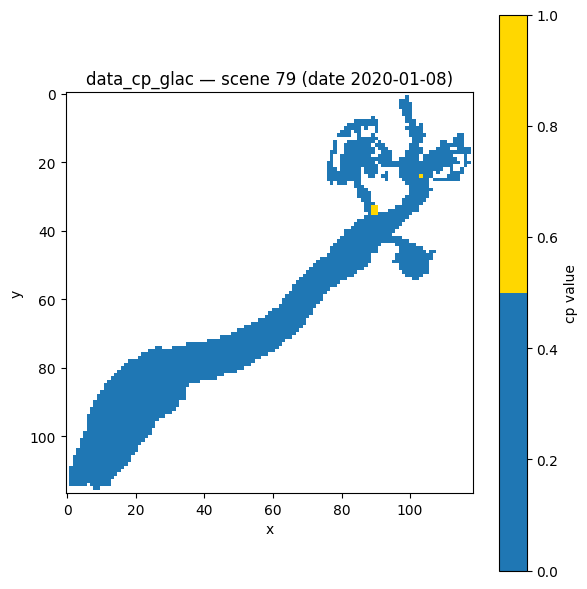

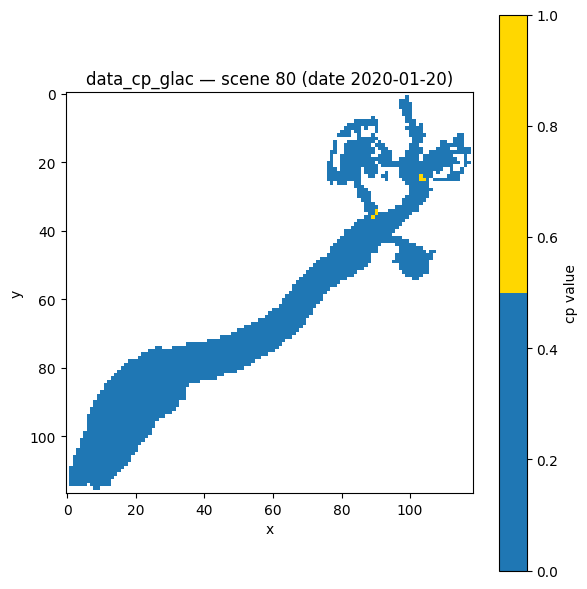

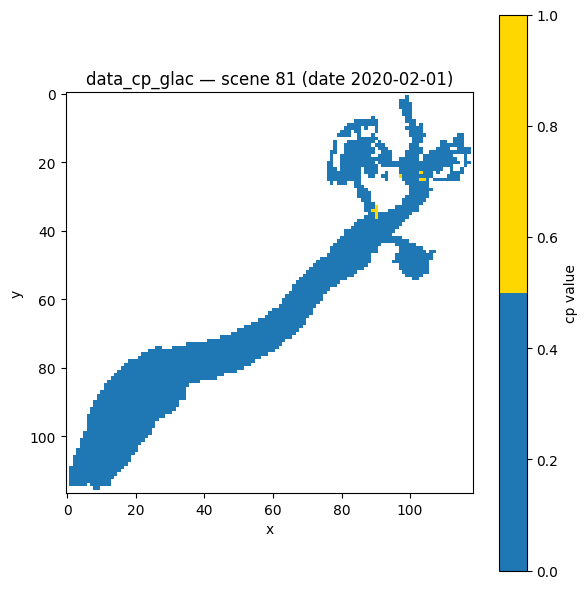

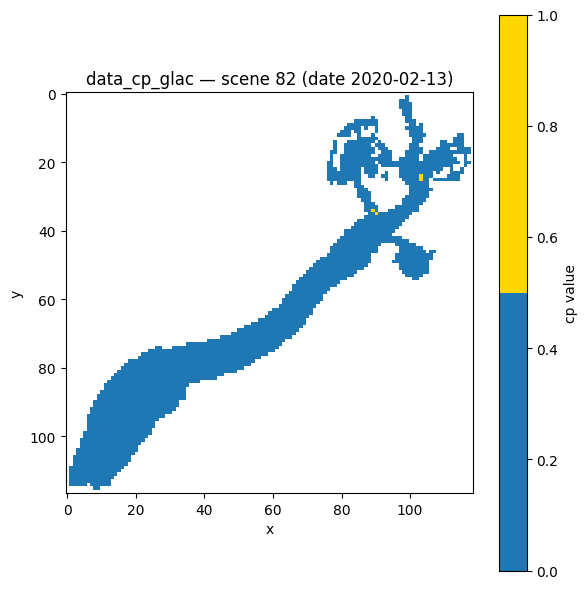

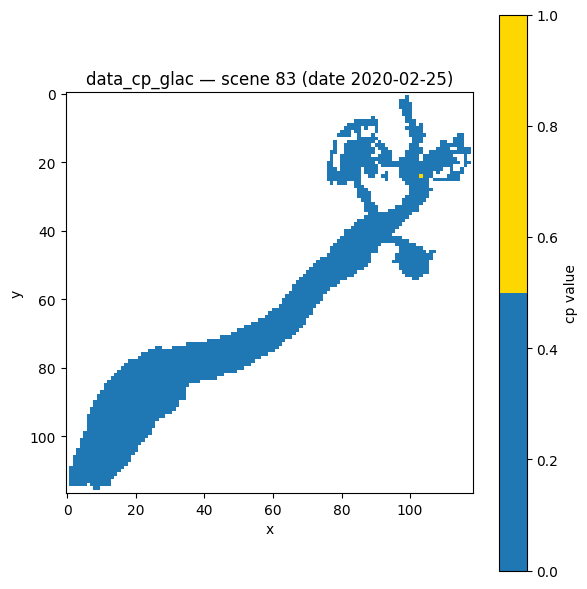

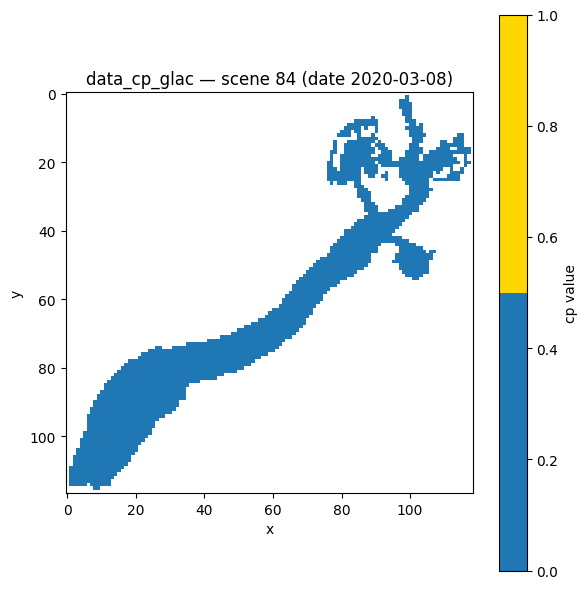

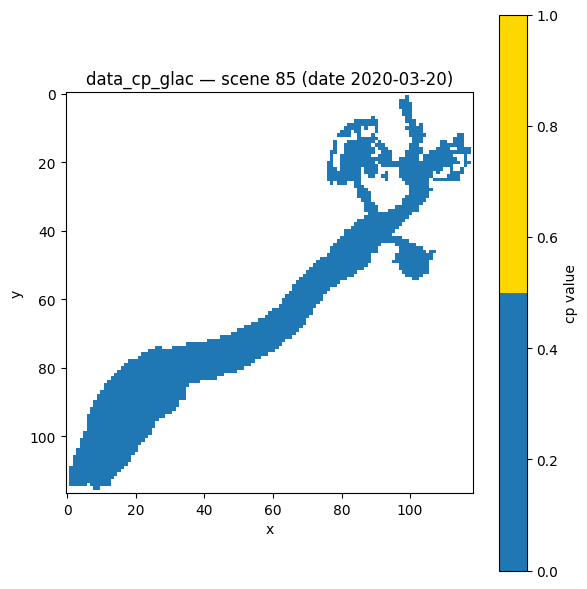

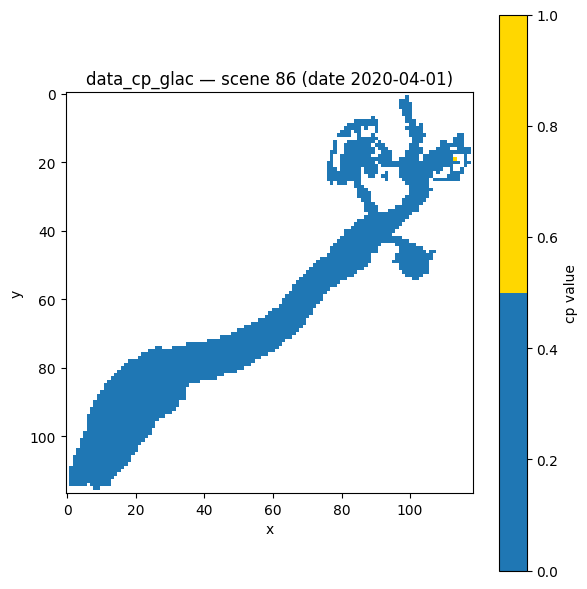

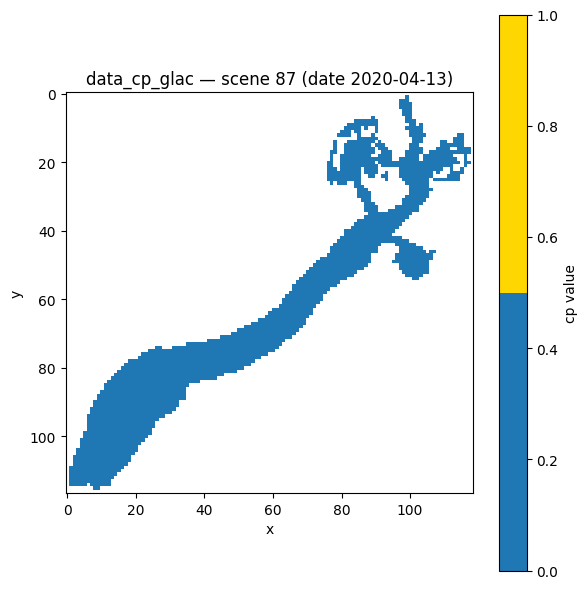

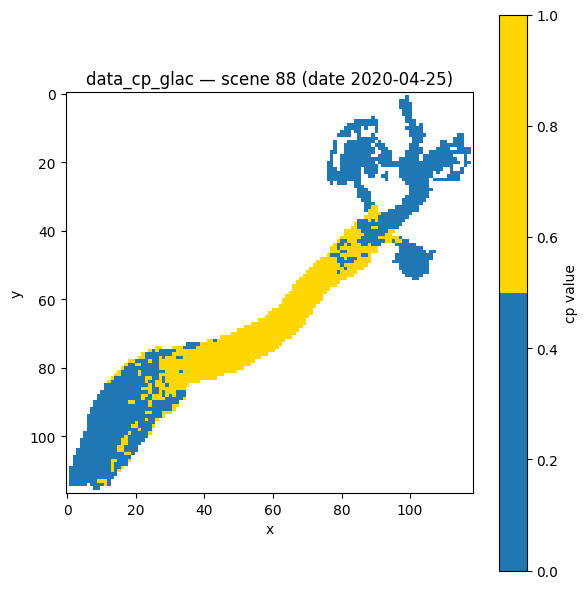

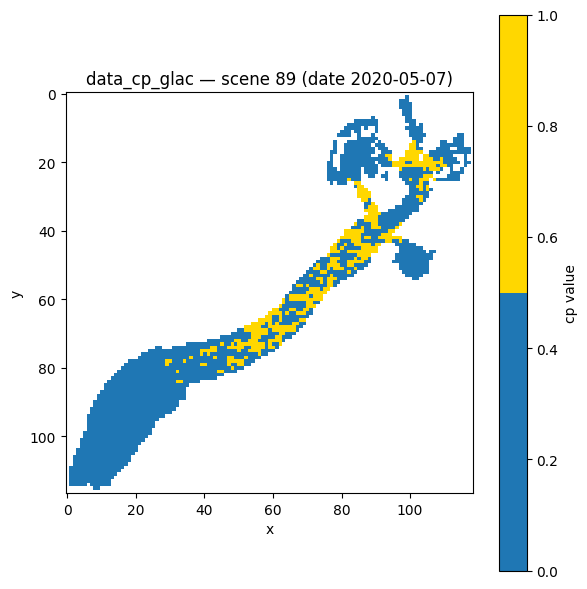

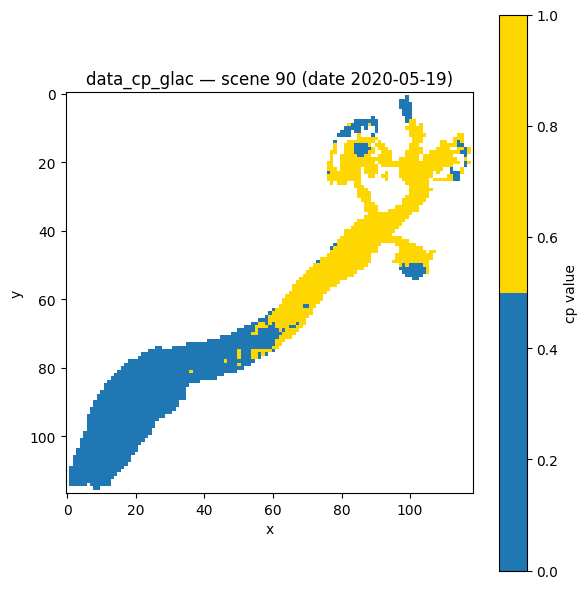

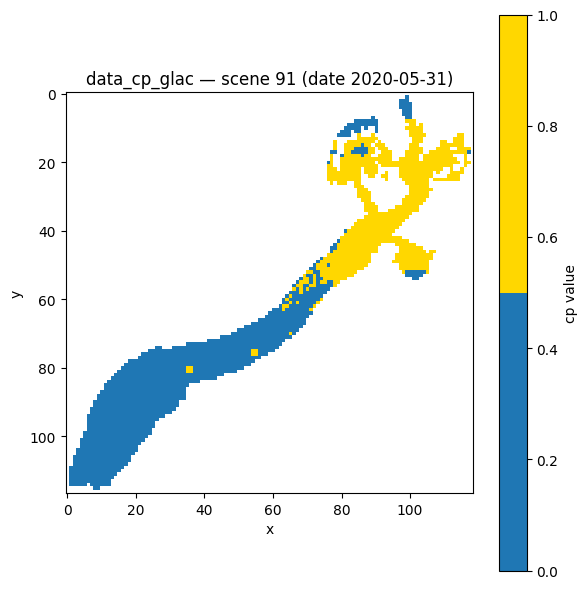

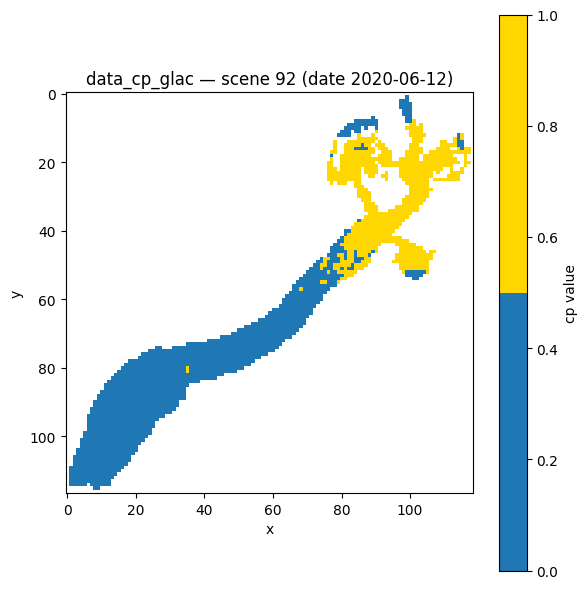

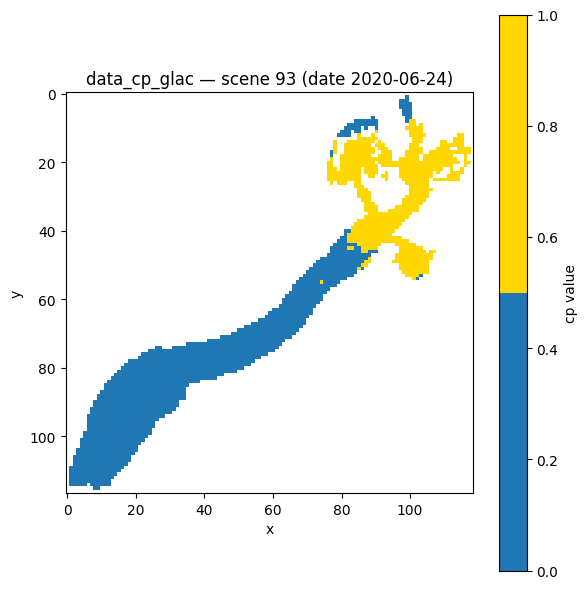

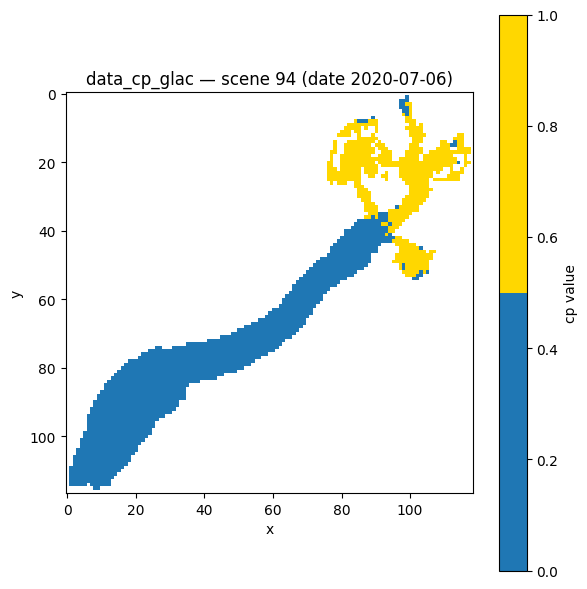

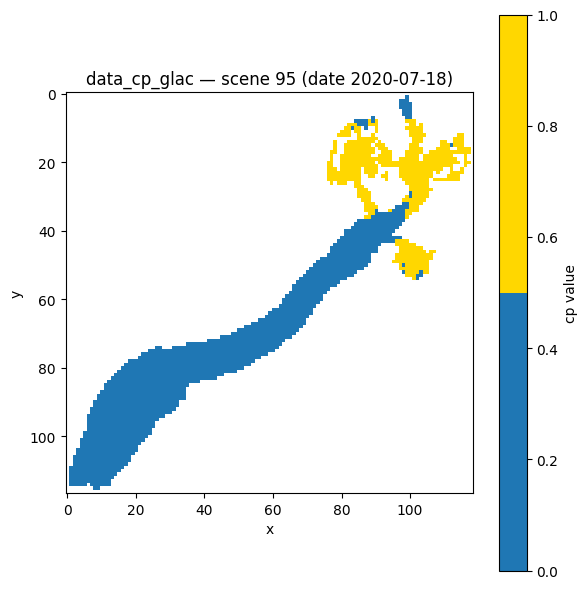

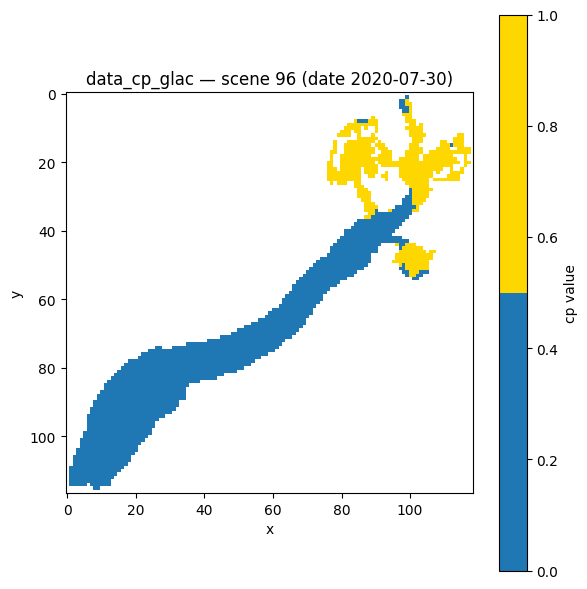

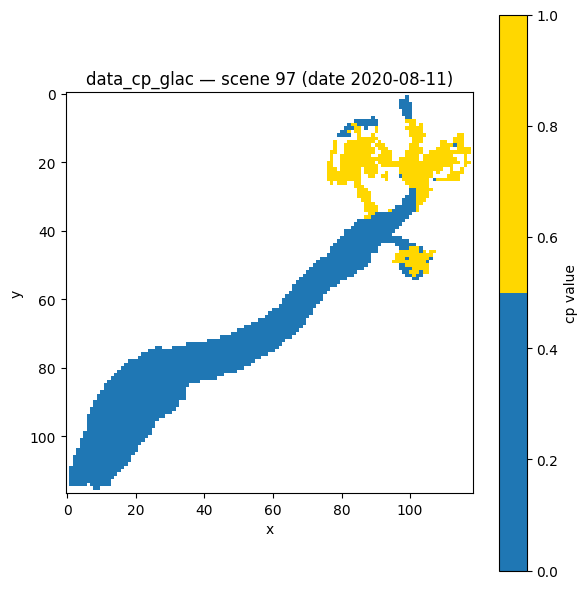

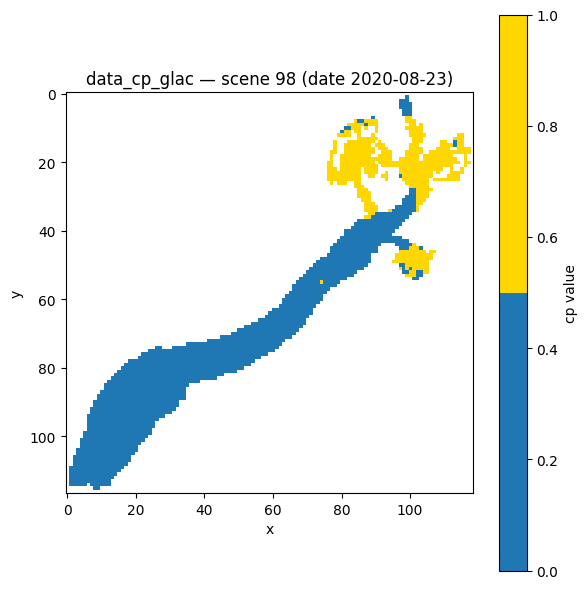

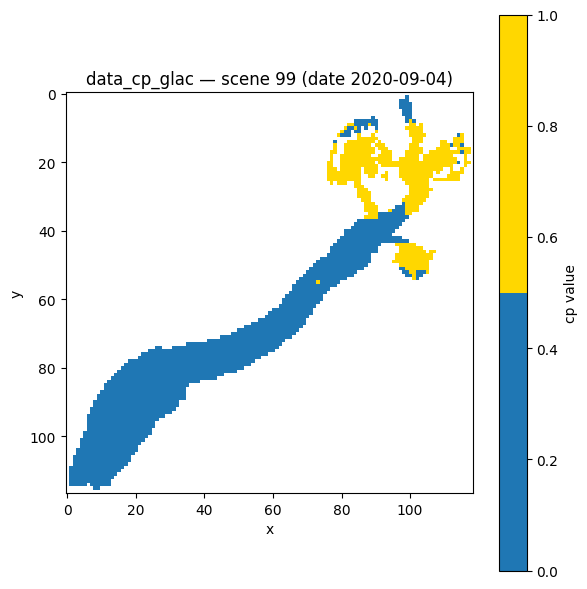

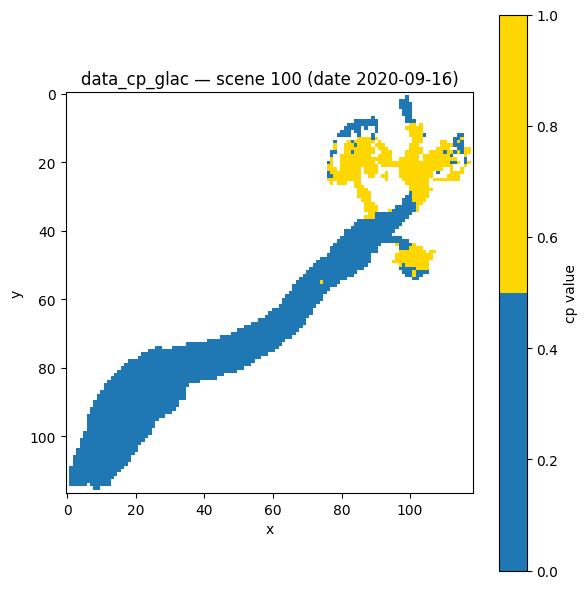

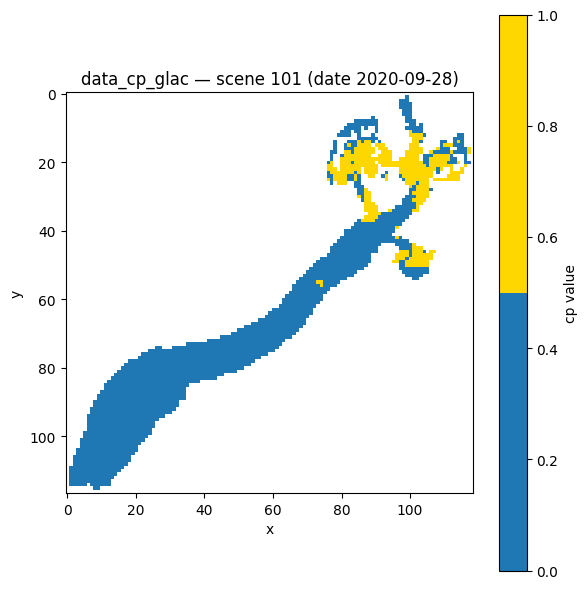

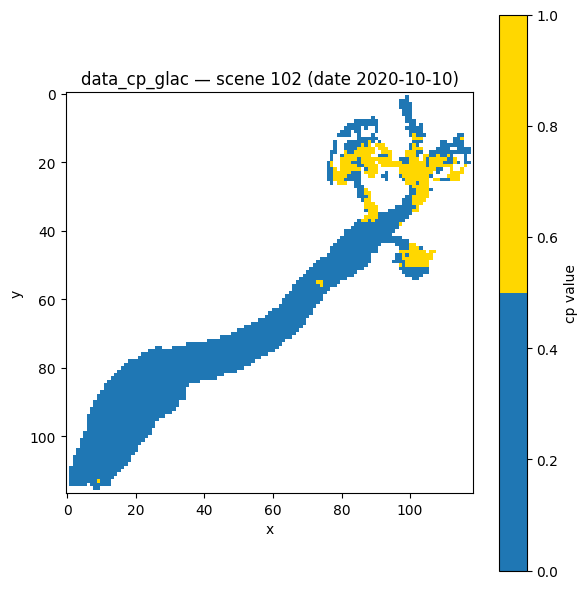

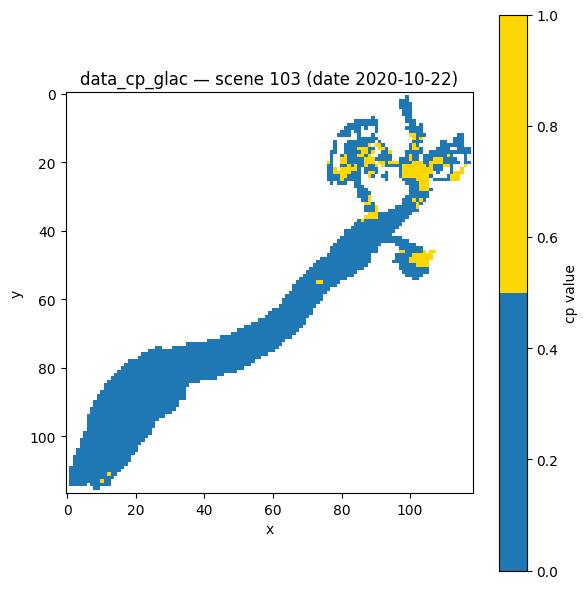

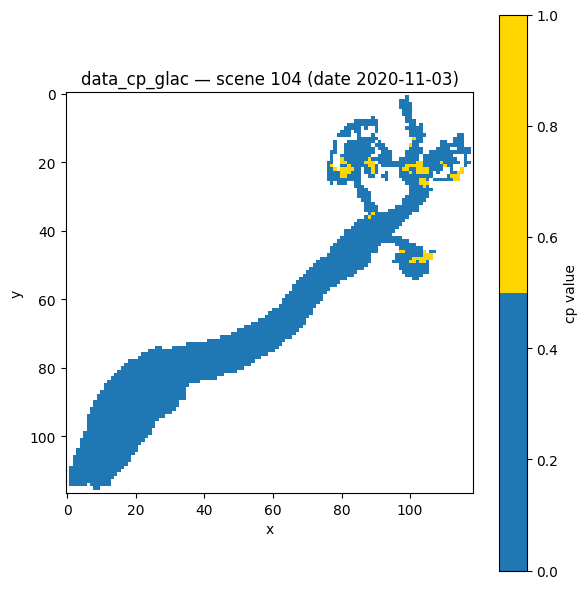

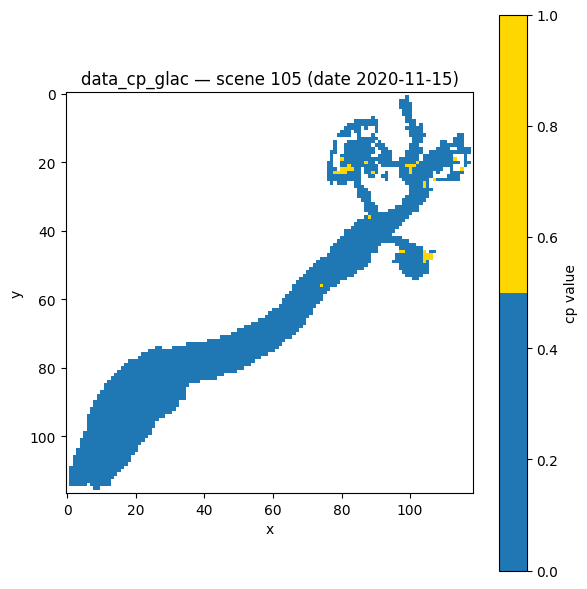

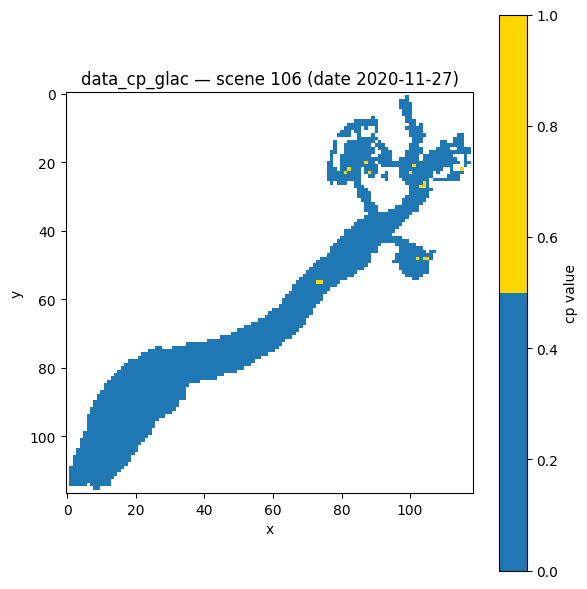

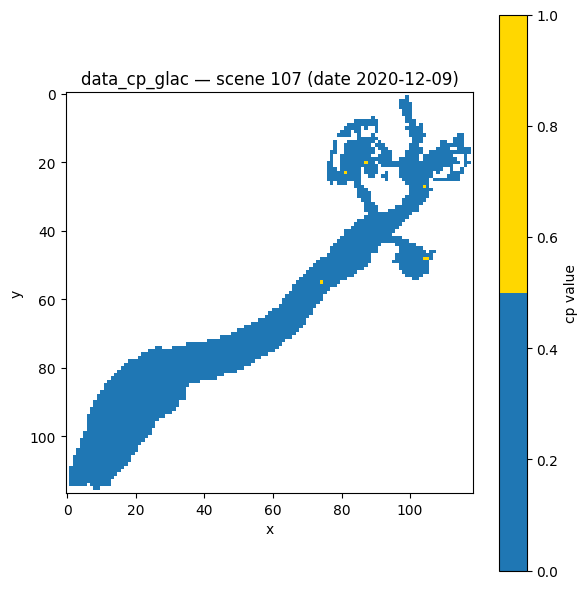

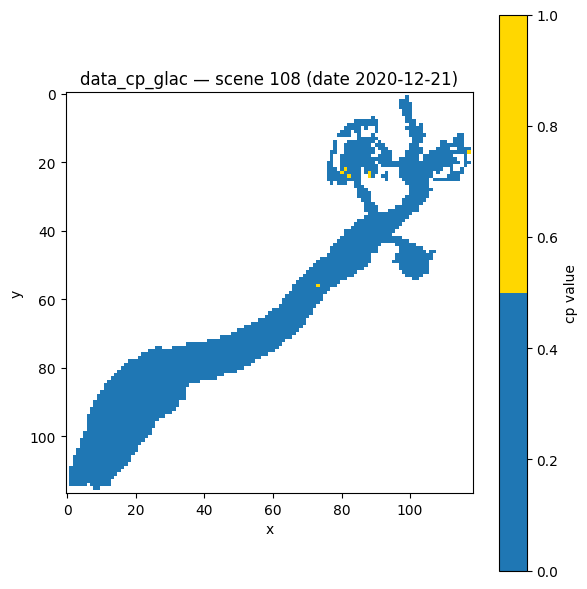

100%|██████████| 1/1 [00:36<00:00, 36.68s/it]

scenes: 226
failed glaciers: 0 [] 



In [167]:
data_nos = [1] # process all data from this path-frame

outer_rng = tqdm(data_nos)
desc=DescStr()
for data_no in outer_rng:
    # load data
    # imagedirsPath = loaded_sar_data[str(data_no)]['imagedirsPath']
    # location_str = loaded_sar_data[str(data_no)]['location_str']
    # scene_name = loaded_sar_data[str(data_no)]['scene_name']
    # epsg_no = loaded_sar_data[str(data_no)]['epsg_no']
    # path_frame_dict = loaded_sar_data[str(data_no)]['path_frame_dict']
    # path_direction = loaded_sar_data[str(data_no)]['Direction']
    # frame_cut = loaded_sar_data[str(data_no)]['frame_cut']
    # loaded_sar_data[str(data_no)]

    location_str = 'kennicott-Cordoba'
    imagedirsPath = None
    scene_name = 'Kennicott-Cordoba'
    epsg_no = 32607
    path_frame_dict = {'14': ['387']}
    path_direction = 'Ascending'
    frame_cut = 0

    # set up output nc file name start (include epsg code in name)
    out_nc_filename_start = f'{location_str}_{epsg_no}_S1_cube'
    pol_str = 'VH' # can also be 'HV' depending on your data!
    
    # dictionary to contain list of images for each date for each path (could be one image per date, or a pair along orbit from that date)
    indate_and_zips_dict = {x:[] for x in path_frame_dict.keys()}
    ds_fns = []
    # for path in indate_and_zips_dict.keys():
    #     indate_and_zips = indate_and_zips_dict[path]
    
    #     out_nc_filename = str(out_nc) + f'/{out_nc_filename_start}_{pol_str}_{path}_{"_".join(path_frame_dict[path])}.nc'
    #     ds_fns.append(out_nc_filename)

    out_nc_filename = os.path.join(os.getcwd(), "Kennicott_32607_S1_cube_VH_014_387.nc")
    ds_fns.append(out_nc_filename)
    
    # RGI ID vs path-row dictionary
    # makes it easier to access individual runs later on; code simply appends the path/row scenes for each glacier within a dictionary
    rgi_ds_fn = 'rgino_ds_dict.json'
    if os.path.exists(rgi_ds_fn):
        with open(rgi_ds_fn, 'r') as json_file:
            rgino_ds_dict = json.load(json_file)
    else:
        rgino_ds_dict = {}
    
    scenes_no, failed_glacnos = process_datacube_to_melt_extent(i=data_no, outer_rng=outer_rng, desc=desc, ds_fns=ds_fns, 
            scene_name=scene_name, rgi_reg=rgi_reg, xres=xres, yres=yres, min_glac_area_km2=min_glac_area_km2, 
            db_threshold=db_threshold, db_threshold_sl=db_threshold_sl, zscore_threshold=zscore_threshold, winter_months=winter_months, 
            snowmelt_months=snowmelt_months, months2exclude_cp=months2exclude_cp, winter_std_threshold=winter_std_threshold, 
            bin_size=bin_size, area_bin_size=area_bin_size, allmelt_threshold=allmelt_threshold, allmelt_pixels=allmelt_pixels)
    print('scenes:', scenes_no)
    print('failed glaciers:', len(failed_glacnos), failed_glacnos, '\n')


Reorganize files into a folder for each glacier

In [150]:
# run this code to reorganize csv files into folders
import shutil

# get all files matching the pattern "01.XXXXX*"
main_directory = os.getcwd()
csv_fp = main_directory + '/csv/'
csv_files = glob.glob(os.path.join(csv_fp, f"{str(rgi_reg).zfill(2)}.[0-9]*.csv"))


# Process each file
for csv_file in csv_files:
    csv_fn = os.path.basename(csv_file)
    glacier_name = csv_fn[:8] # extract glacier name (first 8 characters: "01.XXXXX")

    glac_folder = os.path.join(csv_fp, glacier_name) # create the target directory if it doesn't exist
    os.makedirs(glac_folder, exist_ok=True)

    shutil.move(csv_file, os.path.join(glac_folder, csv_fn)) # move the file to its corresponding glacier folder
